# Исследовательский анализ данных: бронирования билетов на Яндекс Афише (июнь–октябрь 2024)

- Автор: Валеева Евгения
- Дата: 28.02.2026

## Постановка задачи
Заказчик исследования — сервис Яндекс Афиша. Продуктовый отдел отметил изменение пользовательского спроса, причины которого неясны. Необходимо определить, связано ли это с сезонностью, изменением пользовательских предпочтений или составом аудитории.

В рамках исследования требуется провести анализ данных, чтобы:
- выявить популярные категории событий, площадки и организаторов;
- оценить выручку и стоимость билетов;
- сравнить активность пользователей на мобильных и десктопных устройствах.

Цель исследования — выявить ключевые изменения в пользовательском спросе и сформулировать выводы для продуктовой команды.

**План работы**   
1. Загрузить данные и познакомиться с ними: изучить их объем, оценить содержимое, проанализировать типы данных.
2. Предобработка данных и подготовка их к исследованию:
- проверить данные на пропуски;
- изучить значения в ключевых столбцах для категориальных и количественных значений;
- проверить явные дубликаты;
- проверить наличие неявных дубликатах по бронированию билета без учёта идентификаторов заказа;
- проведите преобразования типов данных при необходимости с возможностью снижения размерности количественных данных;
- создать несколько новых столбцов: revenue_rub, one_ticket_revenue_rub, month, season.
3. Исследовательский анализ данных 

3.1. Анализ распределения заказов по сегментам и их сезонные изменения
- изучить динамику по типам мероприятия, типам устройств и возрастному рейтингу;
- для каждого месяца найти количество заказов и визуализировать результаты;
- сравнить летние и осенние периоды по долям заказов в разных категориях;
- проанализировать изменение средней выручки с билета по типам мероприятий.
3.2. Осенняя активность пользователей
- изучить динамику изменений по дням для: общего числа заказов, количества активных пользователей DAU, среднего числа заказов на одного пользователя, средней стоимости одного билета. Полученные результаты визуализировать с помощью линейного графика;
- проанализировать недельную цикличность: будней и выходных.\
3.3. Популярные события и партнёры
- исследовать распределение событий по регионам;
- оценить вклад билетных партнёров в выручку и количество заказов.
4. Статистический анализ данных.  
Проверить  две гипотезы, которые предполагают большую активность пользователей мобильных устройств:
- Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.
- Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.
5. Написать общий вывод и рекомендации:
- информация о данных, с которыми была произведена работа
- основные результаты анализа
- результаты проверки гипотез
- рекомендации, на что обратить внимание

## Описание данных

 **Основные датасеты**
1. `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. 
2. `final_tickets_events_df.csv` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. 
Вспомогательный датасет `final_tickets_tenge_df.csv` с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге.  

## Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных и подготовка их к исследованию.
3. Исследовательский анализ данных.
4. Статистический анализ данных.
5. Итоговый вывод и рекомендации.

## 1. Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns 

# Импорт для красивого вывода таблиц в Jupyter
from IPython.display import display

# Убираем предупреждения
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Выгружаем данные с датасета final_tickets_orders_df.csv в переменную tickets_orders
tickets_orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')

In [3]:
# Выводим первые 5 строк полученного датафрейма на экран
tickets_orders.head(5)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
# Выводим информацию о датафрейме
tickets_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Итого датасет `final_tickets_orders_df.csv`, который включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных, содержит 14 столбцов и 290849 строк.
- Пропуски наблюдаются только в столбце `days_since_prev`, что является ожидаемым.
- Значения в столбцах соответствуют своему описанию.
- Столбцы с датами `created_dt_msk` и `created_ts_msk` приведем к нужному формату datetime64.
- Снизим размерность количественных данных в столбцах: 
 - целочисленные столбцы (`order_id, event_id, age_limit, tickets_count`) переведем в более экономичный тип int32
 - вещественные столбцы (`revenue, total`) переведем в float32 для снижения потребления памяти.

In [5]:
# Выгрузим данные с датасета final_tickets_events_df.csv в переменную tickets_events
tickets_events = pd.read_csv('/datasets/final_tickets_events_df.csv')

In [6]:
# Выводим первые 5 строк полученного датафрейма на экран
tickets_events.head(5)

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [7]:
# Выводим информацию о датафрейме
tickets_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


Итого датасет `final_tickets_orders_df.csv`, содержащий информацию о событиях, площадках, городах и регион события, имеет 11 столбцов и 22427 строк.
- Пропусков в столбцах нет.
- Значения в столбцах соответствуют своему описанию.
- Снизим размерность количественных данных в столбцах: `event_id, city_id, venue_id` в тип int32 для улучшения производительности.

In [8]:
# Загрузим вспомогательный датасет final_tickets_tenge_df.csv с курсом в тенге в переменную tickets_tenge
tickets_tenge = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

In [9]:
# Выводим первые 5 строк полученного датафрейма
tickets_tenge.head(5)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [10]:
# Выводим информацию о датафрейме
tickets_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Итого датасет `final_tickets_tenge_df.csv`, хранящий с информацией о курсе тенге к российскому рублю за 2024 год, имеет 4 столбца и 357 строк.
- Пропусков в столбцах нет.
- Значения в столбцах соответствуют своему описанию.
- Столбец `data` приведём к типу datetime64 для возможности объединения с заказами по дате.
- Столбцы с количественными данными:
 - `nominal` переведём в int32 (значения всегда 100)
 - `curs` переведём в float32 для экономии памяти

## 2. Предобработка данных и подготовка их к исследованию

Объединим данные двух датасетов `final_tickets_orders_df.csv` и `final_tickets_events_df.csv` в один датафрейм, а затем проведем общую предобработку.

In [11]:
# Объединяем по event_id
df = tickets_orders.merge(tickets_events, on='event_id', how='left')

In [12]:
# В объединённом датафрейме df приводим столбцы с датами к datetime
date_cols = ['created_dt_msk', 'created_ts_msk']
df[date_cols] = df[date_cols].apply(pd.to_datetime)

# В датасете tickets_tenge тоже столбец с датой приведем к формату datetime
tickets_tenge['data'] = pd.to_datetime(tickets_tenge['data'])

In [13]:
# Проверим форматы
print(df[['created_dt_msk', 'created_ts_msk']].dtypes)
print(tickets_tenge['data'].dtypes)

created_dt_msk    datetime64[ns]
created_ts_msk    datetime64[ns]
dtype: object
datetime64[ns]


Преобразования прошли успешно, теперь может объединить датасет df c tickets_tenge.

In [14]:
# Добавляем курсы валют по дате
df = df.merge(tickets_tenge, left_on='created_dt_msk', right_on='data', how='left')

# Удаляем дублирующийся столбец data
df.drop(columns=['data'], inplace=True)

In [15]:
# Смотрим наш получившийся датафрейм
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290849 non-null  int64         
 1   user_id                 290849 non-null  object        
 2   created_dt_msk          290849 non-null  datetime64[ns]
 3   created_ts_msk          290849 non-null  datetime64[ns]
 4   event_id                290849 non-null  int64         
 5   cinema_circuit          290849 non-null  object        
 6   age_limit               290849 non-null  int64         
 7   currency_code           290849 non-null  object        
 8   device_type_canonical   290849 non-null  object        
 9   revenue                 290849 non-null  float64       
 10  service_name            290849 non-null  object        
 11  tickets_count           290849 non-null  int64         
 12  total                   290849

- Объединение прошло корректно, все ожидаемые столбца на месте. 
- В датафрейме 290 849 строк — количество строк не изменилось, что говорит о сохранении всех заказов.
- Мы наблюдаем, что столбцы  city_id, venue_id после merge с pandas автоматически перевёл их в float64, потому что появились NaN.

### Работа с пропусками

In [16]:
# Количество пропусков в абсолютных значениях в датасете
df.isna().sum().sort_values(ascending=False)

days_since_prev           21940
event_name                  238
venue_address               238
venue_name                  238
venue_id                    238
city_id                     238
city_name                   238
region_name                 238
organizers                  238
event_type_main             238
event_type_description      238
curs                          0
nominal                       0
order_id                      0
user_id                       0
total                         0
tickets_count                 0
service_name                  0
revenue                       0
device_type_canonical         0
currency_code                 0
age_limit                     0
cinema_circuit                0
event_id                      0
created_ts_msk                0
created_dt_msk                0
cdx                           0
dtype: int64

In [17]:
# Количество пропусков в относительных значениях
df.isna().mean().sort_values(ascending=False)*100

days_since_prev           7.543433
event_name                0.081829
venue_address             0.081829
venue_name                0.081829
venue_id                  0.081829
city_id                   0.081829
city_name                 0.081829
region_name               0.081829
organizers                0.081829
event_type_main           0.081829
event_type_description    0.081829
curs                      0.000000
nominal                   0.000000
order_id                  0.000000
user_id                   0.000000
total                     0.000000
tickets_count             0.000000
service_name              0.000000
revenue                   0.000000
device_type_canonical     0.000000
currency_code             0.000000
age_limit                 0.000000
cinema_circuit            0.000000
event_id                  0.000000
created_ts_msk            0.000000
created_dt_msk            0.000000
cdx                       0.000000
dtype: float64

- После объединения датасетов в столбцах, относящихся к событиям `(event_name, event_type_description, event_type_main, organizers, region_name, city_name, city_id, venue_id, venue_name, venue_address)`, появились пропуски.
- Их доля составляет около 0,08% (238 из 290 849 строк), что незначительно и не повлияет на результаты анализа.
- Удалим строки с пропусками в этих столбцах, это не повлияет на дальнейший исследовательский анализ.
- Пропуски в столбце `days_since_prev` ожидаемы (первые заказы пользователей), поэтому удалять или заполнять их не будем.

In [18]:
# Удаляем строки с пропусками в данных о событиях
event_cols = [
    'event_name', 'event_type_description', 'event_type_main', 
    'organizers', 'region_name', 'city_name', 'city_id', 
    'venue_id', 'venue_name', 'venue_address'
]

df_afisha = df.dropna(subset=event_cols).copy()

print(f"Было строк: {len(df)}")
print(f"Стало строк: {len(df_afisha)}")
print(f"Удалено {len(df) - len(df_afisha)} строк с пропусками")

Было строк: 290849
Стало строк: 290611
Удалено 238 строк с пропусками


In [19]:
# Посмотрим на количество пропусков 
df_afisha.isna().sum().sort_values(ascending=False)

days_since_prev           21913
event_name                    0
curs                          0
nominal                       0
venue_address                 0
venue_name                    0
venue_id                      0
city_id                       0
city_name                     0
region_name                   0
organizers                    0
event_type_main               0
event_type_description        0
order_id                      0
user_id                       0
total                         0
tickets_count                 0
service_name                  0
revenue                       0
device_type_canonical         0
currency_code                 0
age_limit                     0
cinema_circuit                0
event_id                      0
created_ts_msk                0
created_dt_msk                0
cdx                           0
dtype: int64

Пропуски удалены успешно.

### Изучение значений в ключевых столбцах для категориальных и количественных значений

In [20]:
# Посмотрим уникальные значения в ключевых категориальных столбцах
cat_cols = [
    'age_limit',
    'currency_code',
    'device_type_canonical',
    'event_type_main',
    'region_name',
    'city_name',
    'venue_name',
    'cinema_circuit'
]

for col in cat_cols:
    print(f"\n{col}:")
    print(df_afisha[col].value_counts().head(10))
    print(f"Уникальные значения: {df_afisha[col].nunique()}")



age_limit:
16    78556
12    62474
0     61487
6     52161
18    35933
Name: age_limit, dtype: int64
Уникальные значения: 5

currency_code:
rub    285542
kzt      5069
Name: currency_code, dtype: int64
Уникальные значения: 2

device_type_canonical:
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64
Уникальные значения: 2

event_type_main:
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64
Уникальные значения: 7

region_name:
Каменевский регион         91058
Североярская область       44049
Широковская область        16457
Медовская область          13901
Озернинский край           10476
Светополянский округ        7607
Малиновоярский округ        6618
Речиновская область         6293
Солнечноземская область     6288
Яблоневская область         6181
Name: region_name, dtype: int64
Уникальные значения: 81

city_name:
Глиногорск      89446
Озёрс

In [21]:
hidden = ['', ' ', 'нет', 'none', 'unknown', 'null']
print("Скрытые пропуски:")
for col in cat_cols:
    count = df_afisha[col].isin(hidden).sum()
    print(f"{col}: {count}")

Скрытые пропуски:
age_limit: 0
currency_code: 0
device_type_canonical: 0
event_type_main: 0
region_name: 0
city_name: 0
venue_name: 0
cinema_circuit: 289213


В столбце `cinema_circuit` значение "нет" не является пропуском, а означает отсутствие принадлежности к сети кинотеатров.

In [22]:
# Значение "нет" в столбце cinema_circuit поменяем на "без сети"
df_afisha['cinema_circuit'] = df_afisha['cinema_circuit'].replace('нет', 'без сети')

В ходе анализа категориальных столбцов `(age_limit, currency_code, device_type_canonical, event_type_main, region_name, city_name, venue_name, cinema_circuit)` можно сделать следующие выводы:
- В столбце `cinema_circuit` значение "нет" означает отсутствие сети (не пропуск), поэтому для удобства интерпретации это значение было заменено на "без сети".
- В других категориальных столбцах (`age_limit, currency_code, device_type_canonical,event_type_main, region_name, city_name, venue_name`) скрытых пропусков ('', ' ', 'нет', 'none', 'unknown', 'null') не обнаружено.
- Дополнительная нормализация не требуется: значения уже приведены к единому регистру и не содержат лишних пробелов.
- Количество уникальных значений варьируется от 2 `(currency_code, device_type_canonical)` до 3217 `(venue_name)`, что соответствует характеру данных.\
В целом категориальные признаки выглядят корректно и пригодны для дальнейшего анализа.

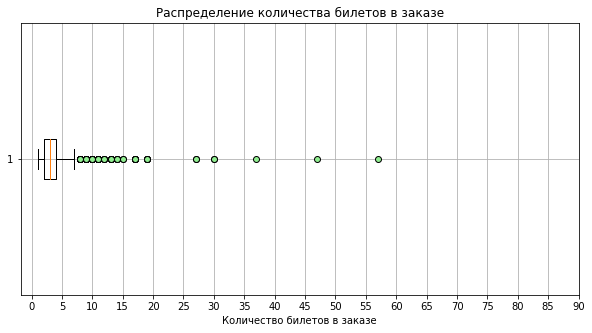

In [23]:
# Построим диаграмму размаха, чтобы посмотреть распределение и наличие выбросов в столбце tickets_count
plt.figure(figsize=(10, 5))
plt.boxplot(df_afisha['tickets_count'],
            vert=False,
            flierprops=dict(markerfacecolor='lightgreen', marker='o'))
# Устанавливаем метки на оси X
plt.xticks(np.arange(0, 91, 5))
plt.title('Распределение количества билетов в заказе')
plt.xlabel('Количество билетов в заказе')
plt.grid(True)
plt.show()

- Медиана количества билетов в заказе — 3. Половина заказов содержит не более 3 билетов.
- Основная масса заказов (50%) приходится на диапазон от 2 до 4 билетов.
- Усы простираются до 6–7 билетов — заказы с таким количеством билетов встречаются реже, но ещё не считаются выбросами.
- Выбросы наблюдаются в диапазоне от 7 до 57 билетов — это редкие заказы с аномально большим количеством билетов. Такие значения встречаются единично и могут соответствовать групповым покупкам (школьные классы, корпоративы).\
Построим гистограмму для выбросов, чтобы детальнее изучить структуру крупных заказов.

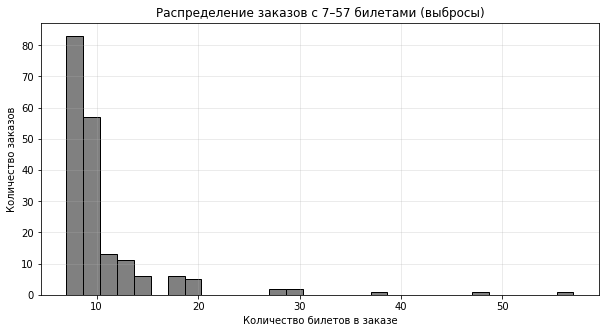

Всего заказов-выбросов: 188
Это 0.06% от всех заказов


In [24]:
# Отфильтруем только выбросы (от 7 до 57 билетов)
outliers = df_afisha[(df_afisha['tickets_count'] >= 7) & (df_afisha['tickets_count'] <= 57)]

plt.figure(figsize=(10, 5))
plt.hist(outliers['tickets_count'], bins=30, edgecolor='black', color='gray')
plt.title('Распределение заказов с 7–57 билетами (выбросы)')
plt.xlabel('Количество билетов в заказе')
plt.ylabel('Количество заказов')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Всего заказов-выбросов: {len(outliers)}")
print(f"Это {len(outliers)/len(df_afisha)*100:.2f}% от всех заказов")

Заказы с 7–57 билетами составляют всего 0,06% (188 заказов). Их доля крайне мала, поэтому они не искажают общую картину. Оставляем их в данных как часть реального пользовательского поведения.

Дальше перейдем к анализу выручки с заказа `revenue`.

In [25]:
# Посчитаем отдельно рубли и тенге
rub_df = df_afisha[df_afisha['currency_code'] == 'rub'].copy()
kzt_df = df_afisha[df_afisha['currency_code'] == 'kzt'].copy()

print(f"Рубли: {len(rub_df)} заказов")
print(f"Тенге: {len(kzt_df)} заказов")

Рубли: 285542 заказов
Тенге: 5069 заказов


In [26]:
# Посчитаем статистику по выручке
print("Статистика по выручке в рублях:")
print(rub_df['revenue'].describe().round(2))

print("Статистика по выручке в тенге:")
print(kzt_df['revenue'].describe().round(2))

Статистика по выручке в рублях:
count    285542.00
mean        548.01
std         871.75
min         -90.76
25%         114.17
50%         346.63
75%         793.32
max       81174.54
Name: revenue, dtype: float64
Статистика по выручке в тенге:
count     5069.00
mean      4995.21
std       4916.75
min          0.00
25%        518.10
50%       3698.83
75%       7397.66
max      26425.86
Name: revenue, dtype: float64


- В рублях наблюдается отрицательное минимальное значение (–90.76) - это могут быть возвраты, ошибки или тестовые заказы.
- Средняя выручка выше медианы в обеих валютах, что указывает на наличие крупных заказов-выбросов, смещающих распределение.
- В тенге заказов значительно меньше, но средний чек существенно выше.
- Максимальные значения (81 тыс. руб. и 26 тыс. тенге) - явные выбросы.\
Построим гистограмму распределения и диаграмму размаха.

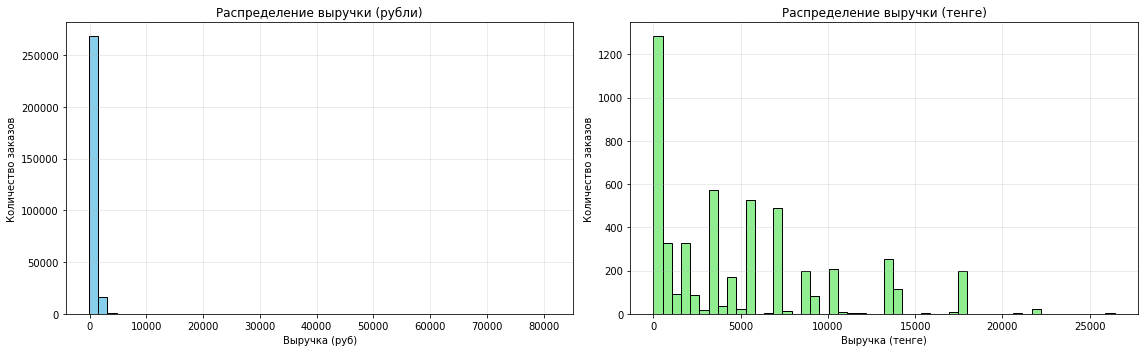

In [27]:
# Построим гистограмму распределения
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Рубли
axes[0].hist(rub_df['revenue'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Распределение выручки (рубли)')
axes[0].set_xlabel('Выручка (руб)')
axes[0].set_ylabel('Количество заказов')
axes[0].grid(True, alpha=0.3)

# Тенге
axes[1].hist(kzt_df['revenue'], bins=50, edgecolor='black', color='lightgreen')
axes[1].set_title('Распределение выручки (тенге)')
axes[1].set_xlabel('Выручка (тенге)')
axes[1].set_ylabel('Количество заказов')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


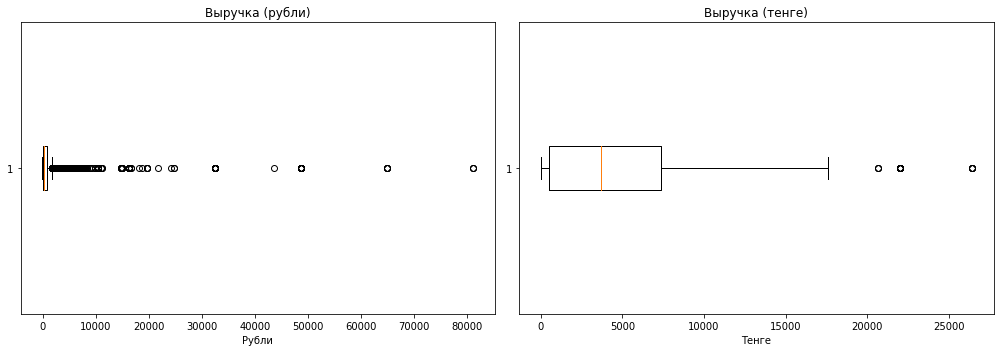

In [28]:
# Построим диаграмму размаха Boxplot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Рубли
axes[0].boxplot(rub_df['revenue'], vert=False)
axes[0].set_title('Выручка (рубли)')
axes[0].set_xlabel('Рубли')

# Тенге
axes[1].boxplot(kzt_df['revenue'], vert=False)
axes[1].set_title('Выручка (тенге)')
axes[1].set_xlabel('Тенге')

plt.tight_layout()
plt.show()

Вывод по гистограммам и диаграммой размаха:
- `Рубли`: основная масса заказов сосредоточена до 2000–3000 руб., распределение имеет длинный правый хвост. На boxplot видны многочисленные выбросы до 80 000 руб., что подтверждает наличие крупных заказов.
- `Тенге`: распределение более равномерное, основная масса заказов — 17 000 тенге. Выбросы достигают 26 000 тенге.

- В обеих валютах наблюдается положительная асимметрия: средняя выручка выше медианы за счёт крупных заказов.
- Отрицательные значения в рублях (до –90 руб.) на графиках не видны из‑за их крайне малого количества, но зафиксированы в статистике.
Отберем значения по 99-му процентилю, чтобы снизить влияние выбросов.

In [29]:
# Отсекаем выбросы по 99-му процентилю
rub_cutoff = rub_df['revenue'].quantile(0.99)
kzt_cutoff = kzt_df['revenue'].quantile(0.99)

rub_clean = rub_df[rub_df['revenue'] <= rub_cutoff].copy()
kzt_clean = kzt_df[kzt_df['revenue'] <= kzt_cutoff].copy()

print(f"Рубли: было {len(rub_df)}, стало {len(rub_clean)} (удалено {len(rub_df) - len(rub_clean)})")
print(f"Тенге: было {len(kzt_df)}, стало {len(kzt_clean)} (удалено {len(kzt_df) - len(kzt_clean)})")

Рубли: было 285542, стало 282742 (удалено 2800)
Тенге: было 5069, стало 5040 (удалено 29)


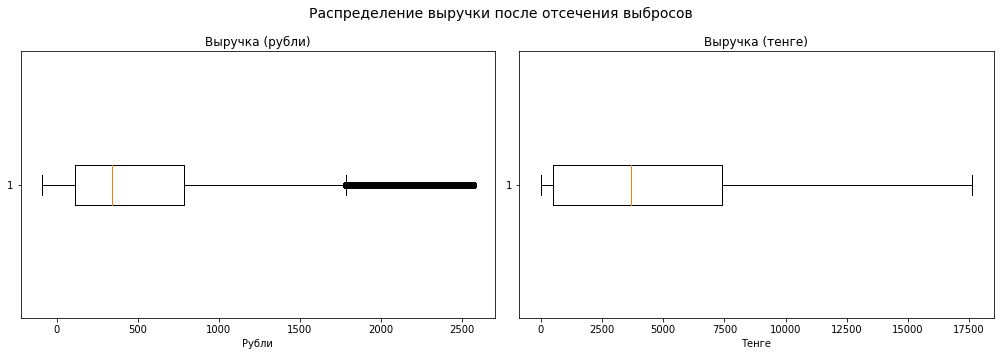

In [30]:
# Построим диаграмму размаха Boxplot, чтобы посмотреть как отфильтровались наши выбросы
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Распределение выручки после отсечения выбросов', fontsize=14)

# Рубли
axes[0].boxplot(rub_clean['revenue'], vert=False)
axes[0].set_title('Выручка (рубли)')
axes[0].set_xlabel('Рубли')

# Тенге
axes[1].boxplot(kzt_clean['revenue'], vert=False)
axes[1].set_title('Выручка (тенге)')
axes[1].set_xlabel('Тенге')

plt.tight_layout()
plt.show()

In [31]:
# Посчитаем статистику по выручке
print("Статистика по выручке в рублях:")
print(rub_clean['revenue'].describe().round(2))

print("Статистика по выручке в тенге:")
print(kzt_clean['revenue'].describe().round(2))

Статистика по выручке в рублях:
count    282742.00
mean        510.81
std         500.93
min         -90.76
25%         112.12
50%         340.66
75%         781.93
max        2570.80
Name: revenue, dtype: float64
Статистика по выручке в тенге:
count     5040.00
mean      4893.67
std       4742.68
min          0.00
25%        515.35
50%       3698.83
75%       7397.66
max      17617.24
Name: revenue, dtype: float64


- Выбросы `в рублях` успешно удалены — максимальная выручка теперь не превышает 2 570р. Среднее снизилось с 548р. до 511р.(теперь ближе к реальности), стандартное отклонение уменьшилось с 872р. до 501р. (данные стали стабильнее)
- `В тенге` также убраны самые крупные заказы, верхняя граница снизилась до 17 617т. Среднее немного снизилось с 4995т. до 4894т.,
стандартное отклонение уменьшилось с 4917т. до 4743т.
- Распределение стало более компактным и пригодным для дальнейшего анализа.
- Единственный недочёт - отрицательные значения в рублях остались. Мы их удалим.

In [32]:
# Удаляем отрицательные значения в рублях
rub_clean = rub_clean[rub_clean['revenue'] >= 0].copy()

# Объединяем очищенные данные по рублям и тенге в один датафрейм для дальнейшего анализа
df_clean = pd.concat([rub_clean, kzt_clean])

### Работа с явными и неявными дубликатами

In [33]:
# Проверяем полные дубликаты в датафрейме df_clean
df_clean.duplicated().sum()

0

In [34]:
# Ищем неявные дубликаты по всем столбцам, кроме order_id
dup_cols = [col for col in df_clean.columns if col != 'order_id']

dup_count = df_clean.duplicated(subset=dup_cols).sum()
print(f'Найдено неявных дубликатов: {dup_count}')

Найдено неявных дубликатов: 30


In [35]:
# Удаляем неявные дубликаты, оставляя первую запись
df_clean = df_clean.drop_duplicates(subset=dup_cols).copy()

In [36]:
# Проверяем, что неявных дубликатов больше нет
dup_count = df_clean.duplicated(subset=dup_cols).sum()
print(f'Неявных дубликатов осталось: {dup_count}')

Неявных дубликатов осталось: 0


In [37]:
# Посчитаем, сколько данных было удалено в ходе очистки
# Размер исходного датафрейма
initial_rows = df.shape[0]

# Размер после очистки
cleaned_rows = df_clean.shape[0]

# Сколько удалили
removed_rows = initial_rows - cleaned_rows
removed_pct = removed_rows / initial_rows * 100

print("Сравнение размеров датафрейма:")
print(f"Исходный датафрейм (df) имеет: {initial_rows:} строк")
print(f"После всех этапов очистки (df_clean) имеет: {cleaned_rows:} строк")
print(f"Удалено: {removed_rows:} строк ({removed_pct:.2f}%)")

Сравнение размеров датафрейма:
Исходный датафрейм (df) имеет: 290849 строк
После всех этапов очистки (df_clean) имеет: 287371 строк
Удалено: 3478 строк (1.20%)


### Снижение размерности данных

In [38]:
df_clean.dtypes

order_id                           int64
user_id                           object
created_dt_msk            datetime64[ns]
created_ts_msk            datetime64[ns]
event_id                           int64
cinema_circuit                    object
age_limit                          int64
currency_code                     object
device_type_canonical             object
revenue                          float64
service_name                      object
tickets_count                      int64
total                            float64
days_since_prev                  float64
event_name                        object
event_type_description            object
event_type_main                   object
organizers                        object
region_name                       object
city_name                         object
city_id                          float64
venue_id                         float64
venue_name                        object
venue_address                     object
nominal         

In [39]:
# Целочисленные столбцы (переводим в int32)
int_cols = ['order_id', 'event_id', 'age_limit', 'tickets_count', 'city_id', 'venue_id', 'nominal']
for col in int_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('int32')

# Вещественные столбцы (переводим в float32)
float_cols = ['revenue', 'total', 'curs', 'days_since_prev']
for col in float_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('float32')
# Проверяем результат преобразований
df_clean.dtypes

order_id                           int32
user_id                           object
created_dt_msk            datetime64[ns]
created_ts_msk            datetime64[ns]
event_id                           int32
cinema_circuit                    object
age_limit                          int32
currency_code                     object
device_type_canonical             object
revenue                          float32
service_name                      object
tickets_count                      int32
total                            float32
days_since_prev                  float32
event_name                        object
event_type_description            object
event_type_main                   object
organizers                        object
region_name                       object
city_name                         object
city_id                            int32
venue_id                           int32
venue_name                        object
venue_address                     object
nominal         

Снижение размерности данных прошло успешно.
- Целочисленные столбцы `(order_id, event_id, age_limit, tickets_count, city_id, venue_id, nominal)` переведены в тип int32 — это позволило сократить занимаемую память без потери точности.
- Вещественные столбцы `(revenue, total, curs, days_since_prev)` переведены в float32 — также для экономии памяти и ускорения вычислений.
- Столбцы `city_id` и `venue_id`, которые ранее стали float64 из-за наличия пропусков, после очистки данных были успешно переведены обратно в целочисленный формат int32.

### Создание новых столбцов

In [40]:
# Создаём столбец revenue_rub (выручка в рублях)
df_clean['revenue_rub'] = np.where(
    df_clean['currency_code'] == 'rub',
    df_clean['revenue'],
    df_clean['revenue'] * df_clean['curs'] / 100)

# Создаём one_ticket_revenue_rub (выручка с одного билета)
df_clean['one_ticket_revenue_rub'] = df_clean['revenue_rub'] / df_clean['tickets_count']

# Создаём month (месяц заказа)
df_clean['month'] = df_clean['created_dt_msk'].dt.month

# Создаём season (сезон)
def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'

df_clean['season'] = df_clean['month'].apply(get_season)
print("Все новые столбцы созданы")
df_clean[['revenue_rub', 'one_ticket_revenue_rub', 'month', 'season']].head()

Все новые столбцы созданы


,revenue_rub,one_ticket_revenue_rub,month,season
0,1521.939941,380.484985,8,лето
1,289.450012,144.725006,7,лето
2,1258.569946,314.642487,10,осень
3,8.490000,4.245000,7,лето
4,1390.410034,463.470011,10,осень


In [41]:
# Снизим размерность новых столбцов revenue_rub и one_ticket_revenue_rub в float32
df_clean['revenue_rub'] = df_clean['revenue_rub'].astype('float32')
df_clean['one_ticket_revenue_rub'] = df_clean['one_ticket_revenue_rub'].astype('float32')

# month в int32
df_clean['month'] = df_clean['month'].astype('int32')

# Проверим результат
print(df_clean[['revenue_rub', 'one_ticket_revenue_rub', 'month']].dtypes)

revenue_rub               float32
one_ticket_revenue_rub    float32
month                       int32
dtype: object


In [42]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287371 entries, 0 to 290727
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287371 non-null  int32         
 1   user_id                 287371 non-null  object        
 2   created_dt_msk          287371 non-null  datetime64[ns]
 3   created_ts_msk          287371 non-null  datetime64[ns]
 4   event_id                287371 non-null  int32         
 5   cinema_circuit          287371 non-null  object        
 6   age_limit               287371 non-null  int32         
 7   currency_code           287371 non-null  object        
 8   device_type_canonical   287371 non-null  object        
 9   revenue                 287371 non-null  float32       
 10  service_name            287371 non-null  object        
 11  tickets_count           287371 non-null  int32         
 12  total                   287371

- после предобработки данных наш датасет `df_clean` имеет 31 столбец и 287358 строк
- столбцы `nominal, curs, cdx` были нужны только для конвертации. После создания столбца revenue_rub они нам больше не нужны, удалим их.

In [43]:
df_clean = df_clean.drop(columns=['nominal', 'curs', 'cdx'])

In [44]:
print(f"Строк: {len(df_clean)}")
print(f"Столбцов: {len(df_clean.columns)}")

Строк: 287371
Столбцов: 28


**Вывод после предобработки данных**:
- Мы объединили 2 основных датасета `final_tickets_orders_df.csv` (данные обо всех заказах, совершенные с мобильных и стационарных устройств), `final_tickets_events_df.csv` (информация о событиях,городах, регионах и площадках) и один дополнительный `final_tickets_tenge_df.csv` (информация о курсе тенге к рублю).
- Удалили 238 строк (0.08%) пропусков в столбцах, относящихся к событиям. Пропуски в столбце `days_since_prev` ожидаемы и мы их оставили в неизменном виде.
- `Изучили значения в ключевых столбцах`:
 - `категориальные` данные корректны, ошибок не выявлено, дополнительная обработка не потребовалась.
 - `в количественном` столбце `tickets_count`(количсетво билетов в заказе) обнаружили выбросы, детальнее ознакомились с ними и приняли решение,что выбросы не искажают общую картину и показывают данные как часть реального пользовательского поведения
 - `в количественном столбце revenue(выручка)` зафиксировали отрицательные значения и крупные выбросы, отобрали данные по 99 процентилю.
- Явных дубликатов обнаружено не было.
- Неявных дубликатов по бронированию билета без учёта идентификаторов заказа, мы обнаружили `83`. Удалили, оставляя первое вхождение.
- В количественных столбцах снизили размерность.
- Создали 4 новых столбца: `revenue_rub` — привели выручку с заказа к российскому рублю, `one_ticket_revenue_rub` — рассчитали выручку с продажи одного билета на мероприятие, `month` — выделили месяц оформления заказа, `season` — создали столбец с информацией о сезонности.
- Удалили столбцы `nominal, curs, cdx` они были нужны только для конвертации.\
Итого наш датасет df_clean после предобработки данных имеет `28 столбцов и 287371 строку`. Было удалено 3478 строк (1.20%).\
Датасет готов к дальнейшему исследовательскому анализу.

## 3. Исследовательский анализ данных

###  3.1. Анализ распределения заказов по сегментам и их сезонные изменения

In [45]:
# Проверим, какие месяцы у нас в данных
sorted(df_clean['month'].unique())

[6, 7, 8, 9, 10]

In [46]:
# Создадим столбец с названиями месяцев для удобства
month_names = {6: 'Июнь', 7: 'Июль', 8: 'Август', 9: 'Сентябрь', 10: 'Октябрь'}
df_clean['month_name'] = df_clean['month'].map(month_names)

# Зададим правильный порядок
month_order = ['Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь']
df_clean['month_name'] = pd.Categorical(
    df_clean['month_name'], 
    categories=month_order, 
    ordered=True
)

# Проверим, что всё правильно
check = df_clean[['month', 'month_name']].drop_duplicates().sort_values('month')
print(check.to_string(index=False))

 month month_name
     6       Июнь
     7       Июль
     8     Август
     9   Сентябрь
    10    Октябрь


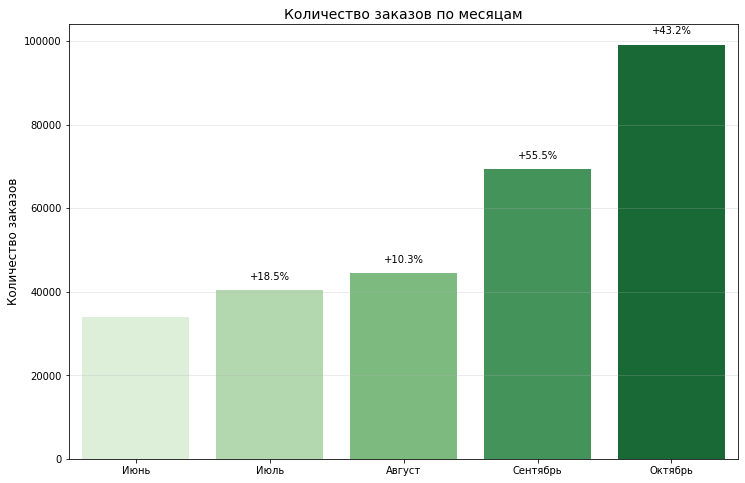

In [47]:
# Считаем количество заказов по месяцам 
orders_by_month = df_clean.groupby('month_name')['order_id'].count().reset_index()
orders_by_month.columns = ['month_name', 'orders_count']

# Добавляем процент роста относительно предыдущего месяца
orders_by_month['perc_month'] = orders_by_month['orders_count'].pct_change() * 100
orders_by_month['perc_month'] = orders_by_month['perc_month'].round(1)

# Строим столбчатую диаграмму
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=orders_by_month, x='month_name', y='orders_count', palette='Greens')

# Добавляем подписи с процентами
for i, (idx, row) in enumerate(orders_by_month.iterrows()):
    if pd.notna(row['perc_month']):
        ax.text(i, row['orders_count'] + 2500, f"+{row['perc_month']}%", 
                ha='center', fontsize=10, color='black')

plt.title('Количество заказов по месяцам', fontsize=14)
plt.xlabel('')
plt.ylabel('Количество заказов', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

- Мы наблюдаем устойчивый рост количества заказов с июня по октябрь 2024 года
- В октябре количество заказов выросло почти в 3 раза по сравнению с июнем.
- Наиболее интенсивный рост пришёлся на сентябрь (+55,5% к августу), что стало началом активного осеннего сезона.

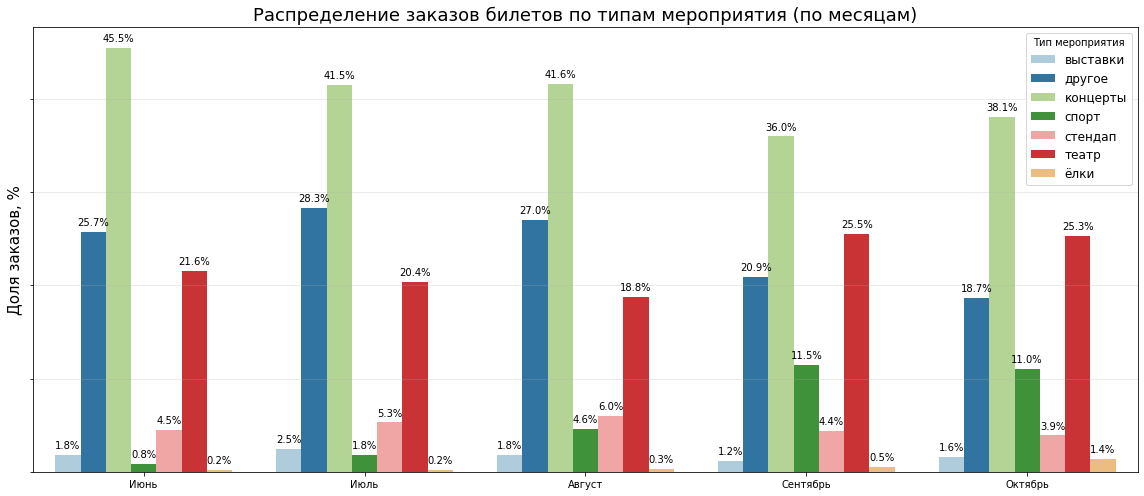

In [48]:
# Посчитаем количество заказов по типам мероприятий
event_month = df_clean.groupby(['month_name', 'event_type_main'])['order_id'].count().reset_index()

# Добавляем долю в процентах для каждого месяца
event_month['perc'] = event_month.groupby('month_name')['order_id'].transform(lambda x: x / x.sum() * 100).round(1)

# Строим столбчатую диаграмму с долями
plt.figure(figsize=(16, 7))
ax = sns.barplot(data=event_month, x='month_name', y='perc', hue='event_type_main', palette='Paired')

# Добавляем подписи значений
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', 
                ha='center', va='bottom', fontsize=10)

plt.title('Распределение заказов билетов по типам мероприятия (по месяцам)', fontsize=18)
plt.xlabel('')
plt.ylabel('Доля заказов, %', fontsize=15)
ax.set_yticklabels([])
plt.legend(title='Тип мероприятия', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- `Концерты` остаются самым популярным типом мероприятий во все месяцы, хотя их доля снижается с 45,5% в июне до 38,1% в октябре.
- `Другое` и `театр` стабильно занимают 2–3 места, причём продажа билетов в театр в сентябре увеличивается.
- `Спорт` демонстрирует впечатляющий рост с 0,8% в июне до 11,5% в сентябре, становясь значимой категорией осенью.
- `Ёлки` начинают набирать популярность в октябре (1,4%), что связано с приближением новогоднего сезона.\
Осенью наблюдается перераспределение спроса — доля концертов снижается, театр выходит на второе место, а спорт становится значимой категорией, что отражает изменение предпочтений аудитории с наступлением холодного сезона.

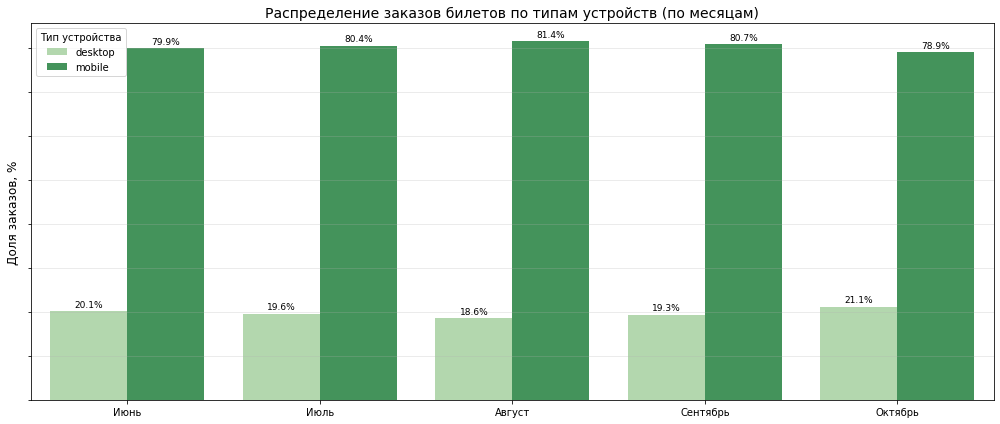

In [49]:
# Посчитаем количество заказов по типам устройств
device_month = df_clean.groupby(['month_name', 'device_type_canonical'])['order_id'].count().reset_index()

# Добавляем долю в процентах для каждого месяца
device_month['perc'] = device_month.groupby('month_name')['order_id'].transform(lambda x: x / x.sum() * 100).round(1)

# Строим столбчатую диаграмму
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=device_month, x='month_name', y='perc', hue='device_type_canonical', palette='Greens')

# Добавляем подписи значений
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 1:
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', 
                    ha='center', va='bottom', fontsize=9)

plt.title('Распределение заказов билетов по типам устройств (по месяцам)', fontsize=14)
plt.xlabel('')
plt.ylabel('Доля заказов, %', fontsize=12)
ax.set_yticklabels([])
plt.legend(title='Тип устройства')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- `Мобильные устройства` остаются доминирующим каналом продаж во все месяцы, занимая 78–81% всех заказов.
- `Стационарные устройства` стабильно удерживают долю 18–21%, с небольшим пиком в октябре (21,1%).
Несмотря на сезонные колебания в общем количестве заказов, структура по типам устройств остаётся стабильной.\
Это означает, что пользователи не меняют свои привычки с наступлением осени — мобильные устройства остаются приоритетным способом покупки билетов.

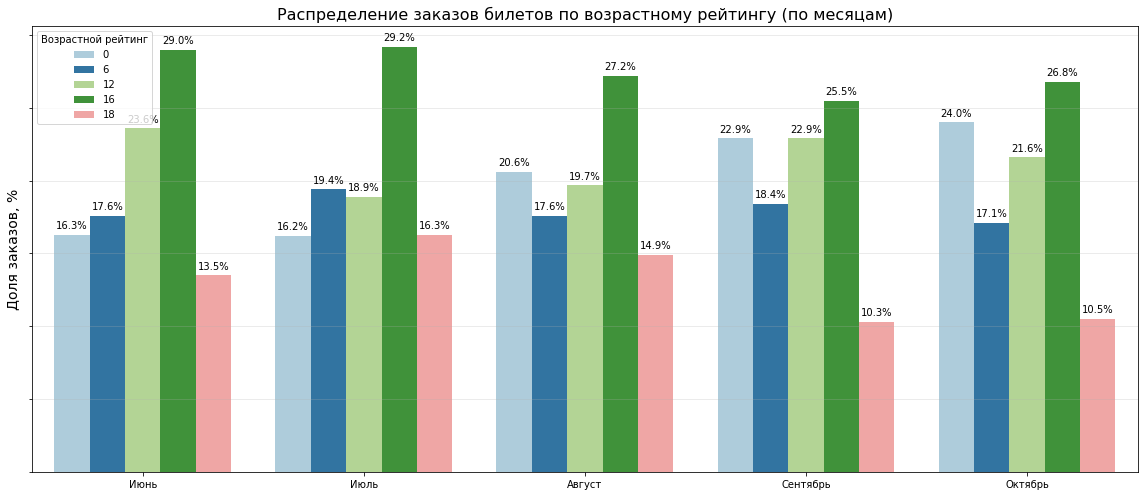

In [50]:
# Посчитаем количество заказов по возрастному рейтингу
age_month = df_clean.groupby(['month_name', 'age_limit'])['order_id'].count().reset_index()

# Добавляем долю в процентах для каждого месяца
age_month['perc'] = age_month.groupby('month_name')['order_id'].transform(lambda x: x / x.sum() * 100).round(1)

# Строим столбчатую диаграмму
plt.figure(figsize=(16, 7))
ax = sns.barplot(data=age_month, x='month_name', y='perc', hue='age_limit', palette='Paired')

# Добавляем подписи значений
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.3, f'{height:.1f}%', 
                ha='center', va='bottom', fontsize=10)

plt.title('Распределение заказов билетов по возрастному рейтингу (по месяцам)', fontsize=16)
plt.xlabel('')
plt.ylabel('Доля заказов, %', fontsize=14)
ax.set_yticklabels([])
plt.legend(title='Возрастной рейтинг')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- 16+ — безусловный лидер во все месяцы (25%–29%), хотя к осени его доля немного снижается.
- 0+ демонстрирует впечатляющий рост (с 16% до 24%), становясь второй по популярности категорией осенью.
- 12+ и 6+ стабильно занимают промежуточные позиции (17–23%).
- 18+ неизменно находится на последнем месте во все месяцы, с долей 10–16%, которая к осени снижается до минимума (10,3–10,5%).
Осенью спрос смещается в сторону мероприятий без возрастных ограничений (0+) и для подростков (12+), в то время как доля категории 18+ остаётся минимальной и продолжает снижаться.

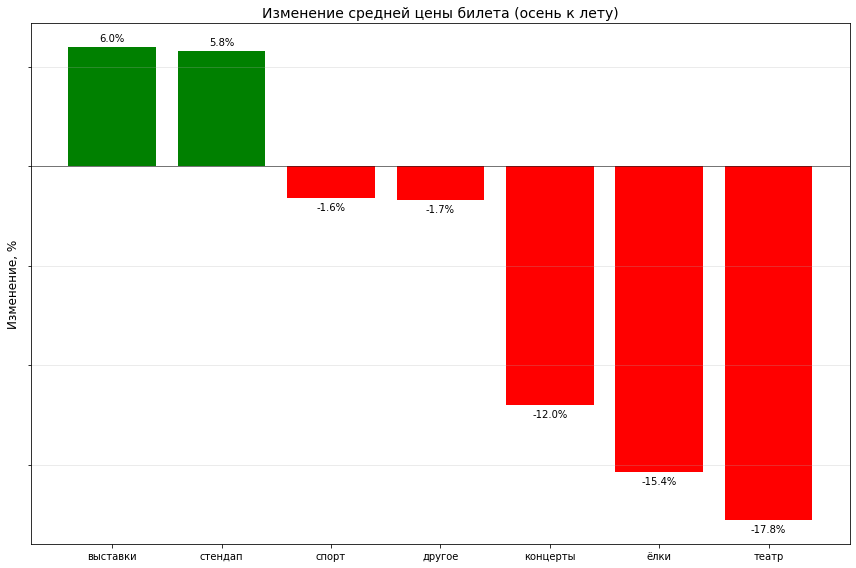

In [51]:
# Изучим изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью
ticket_price = df_clean.groupby(['season', 'event_type_main'])['one_ticket_revenue_rub'].mean().round(2).reset_index()
ticket_price.columns = ['season', 'event_type', 'avg_price']

# Разделяем летние и осенние данные
summer_prices = ticket_price[ticket_price['season'] == 'лето'].set_index('event_type')['avg_price']
autumn_prices = ticket_price[ticket_price['season'] == 'осень'].set_index('event_type')['avg_price']

# Считаем изменение
change_percent = ((autumn_prices - summer_prices) / summer_prices * 100).round(1).sort_values(ascending=False)

# Строим график
plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in change_percent.values]
bars = plt.bar(change_percent.index, change_percent.values, color=colors)

# Добавляем подписи значений на столбцах
for bar in bars:
    height = bar.get_height()
    if height >= 0:
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.2, f'{height:.1f}%', 
                ha='center', va='bottom', fontsize=10)
    else:
        plt.text(bar.get_x() + bar.get_width()/2, height - 0.2, f'{height:.1f}%', 
                ha='center', va='top', fontsize=10)

plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Изменение средней цены билета (осень к лету)', fontsize=14)
plt.ylabel('Изменение, %', fontsize=12)
plt.gca().set_yticklabels([])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- Выставки (+6,0%) и стендап (+5,8%) - единственные категории с ростом цен.
- Концерты (–11,9%), ёлки (–15,4%) и театр (–17,8%) подешевели наиболее заметно.
- Спорт (–1,6%) и другое (–1,7%) остались практически без изменений.

**Вывод, как меняется распределение заказов в каждой категории с наступлением осени**
- Мы увидели устойчивый рост количества заказов с июня по октябрь 2024 года, при том продажа билетов в `театр, спорт и ёлки` увеличилась, но средняя цена одного билета на эти типы мероприятия снизились. Это может быть связано с началом учебного года (рост детских/студенческих мероприятий) либо с запуском сезонных акций.
- У `концертов` снизилось количество проданных билетов и средняя цена одного билета к осени.
- У `выставок` и `стендапа` не наблюдается повышение заказов билетов, но осенью наблюдется подорожание цены одного билета.
- `По типам устройств` изменений не произошло — пользователи стабильно предпочитают мобильные.
- В возрастной структуре осенью наблюдается сдвиг в сторону категорий 0+ и 12+, тогда как доля 18+ остаётся минимальной и продолжает снижаться.

###  3.2. Осенняя активность пользователей

In [52]:
# Оставляем только сентябрь и октябрь
autumn_df = df_clean[df_clean['season'] == 'осень'].copy()

# Проверяем
print(f"Осенних заказов: {len(autumn_df)}")
print(autumn_df['month_name'].value_counts())

Осенних заказов: 168423
Октябрь     99159
Сентябрь    69264
Июнь            0
Июль            0
Август          0
Name: month_name, dtype: int64


In [53]:
# Группируем по дате
daily_stats = autumn_df.groupby('created_dt_msk').agg(
    total_orders=('order_id', 'count'),         
    dau=('user_id', 'nunique'),                   
    total_tickets=('tickets_count', 'sum'),       
    total_revenue=('revenue_rub', 'sum')         
).reset_index()

# Добавляем расчётные метрики
daily_stats['orders_per_user'] = (daily_stats['total_orders'] / daily_stats['dau']).round(2)  
daily_stats['avg_ticket_price'] = (daily_stats['total_revenue'] / daily_stats['total_tickets']).round(2) 

display(daily_stats.head(5))

,created_dt_msk,total_orders,dau,total_tickets,total_revenue,orders_per_user,avg_ticket_price
0,2024-09-01,1327,564,3718,7.262059e+05,2.35,195.32
1,2024-09-02,1376,573,3695,7.035391e+05,2.40,190.40
2,2024-09-03,5094,777,15252,1.156350e+06,6.56,75.82
3,2024-09-04,1760,684,4779,8.596637e+05,2.57,179.88
4,2024-09-05,1941,738,5208,9.894183e+05,2.63,189.98


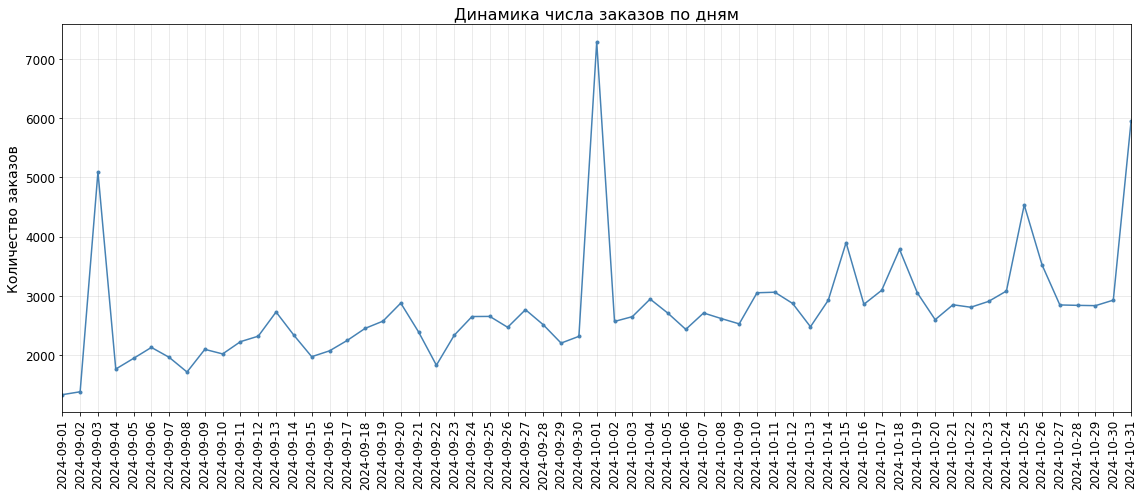

In [54]:
# Построим график для динамики числа заказов по дням
plt.figure(figsize=(16, 7))
plt.plot(daily_stats['created_dt_msk'], daily_stats['total_orders'], marker='o', markersize=3, color='steelblue')
plt.margins(x=0)
plt.title('Динамика числа заказов по дням', fontsize=16)           
plt.xlabel('', fontsize=14)                                    
plt.ylabel('Количество заказов', fontsize=14)                      
plt.xticks(daily_stats['created_dt_msk'][::1], rotation=90, fontsize=12)  
plt.yticks(fontsize=12)                                             
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Мы наблюдаем положительный общий тренд — количество заказов стабильно растёт с сентября по октябрь.\
Пиковые дни активности:
- 3 сентября — резкий скачок (более 5000 заказов)
- 1 октября — абсолютный максимум (более 7000 заказов)
- 31 октября — ещё один высокий пик (более 6000 заказов)\
Дни с наименьшей активностью:
- 1, 2, 4, 8 сентября — начало месяца, возможна "раскачка" после лета
- 22 сентября — локальный минимум

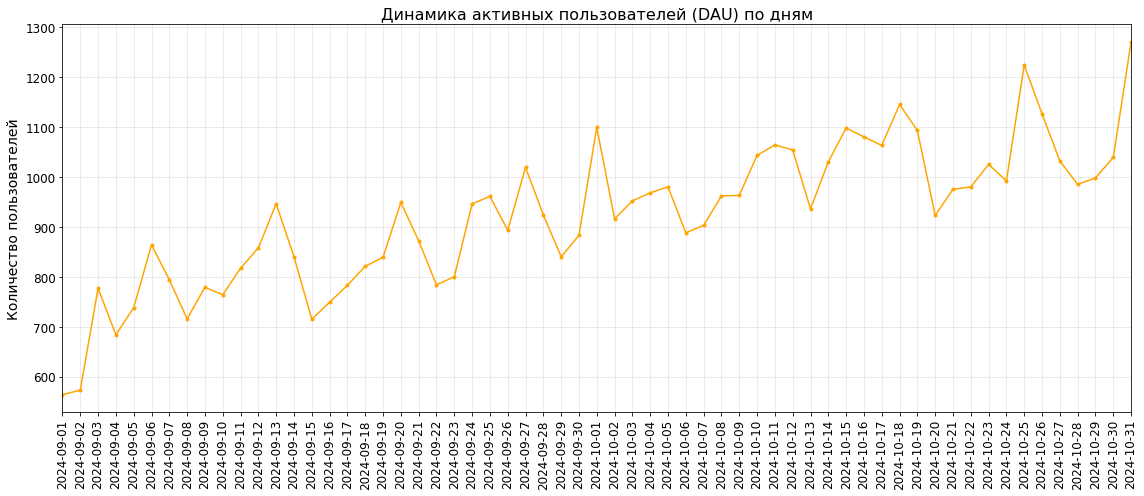

In [55]:
# Построим график для динамики активных пользователей (DAU) по дням
plt.figure(figsize=(16, 7))
plt.plot(daily_stats['created_dt_msk'], daily_stats['dau'], marker='o', markersize=3, color='orange')
plt.margins(x=0)
plt.title('Динамика активных пользователей (DAU) по дням', fontsize=16)           
plt.xlabel('', fontsize=14)                                    
plt.ylabel('Количество пользователей', fontsize=14)                      
plt.xticks(daily_stats['created_dt_msk'][::1], rotation=90, fontsize=12)  
plt.yticks(fontsize=12)                                             
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Мы наблюдаем устойчивый рост количества уникальных пользователей от сентября к октябрю.
- С 3 сентября фиксируется заметное увеличение DAU, что совпадает с началом активного осеннего сезона.\
Пиковые значения:
- 1 октября — более 1100 уникальных пользователей
- 31 октября — более 1300 уникальных пользователей\
Именно рост DAU в эти дни объясняет рекордное количество заказов - больше покупателей привели к большему числу покупок.

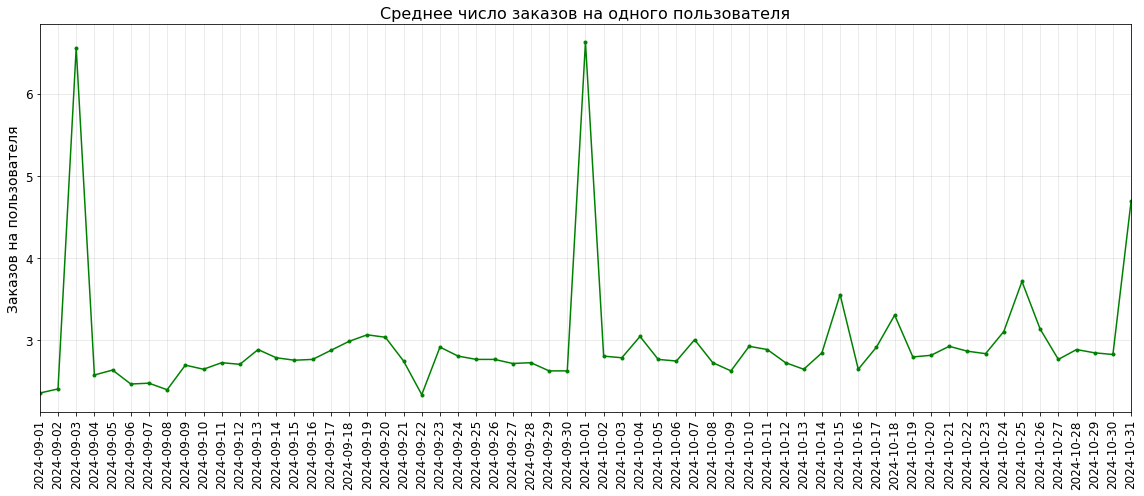

In [56]:
# Построим график для среднего числа заказов на одного пользователя по дням
plt.figure(figsize=(16, 7))
plt.plot(daily_stats['created_dt_msk'], daily_stats['orders_per_user'], marker='o', markersize=3, color='green')
plt.margins(x=0)
plt.title('Среднее число заказов на одного пользователя', fontsize=16)           
plt.xlabel('', fontsize=14)                                    
plt.ylabel('Заказов на пользователя', fontsize=14)                      
plt.xticks(daily_stats['created_dt_msk'][::1], rotation=90, fontsize=12)  
plt.yticks(fontsize=12)                                             
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- В большинство дней показатель держится в диапазоне 2-3 билета на человека.
Ярко выраженные пики зафиксированы:
- 3 сентября и 1 октября — резкий скачок до более 6 билетов
- 31 октября — ещё один всплеск активности
Минимальные значения приходятся на: 1, 2, 8 и 22 сентября.

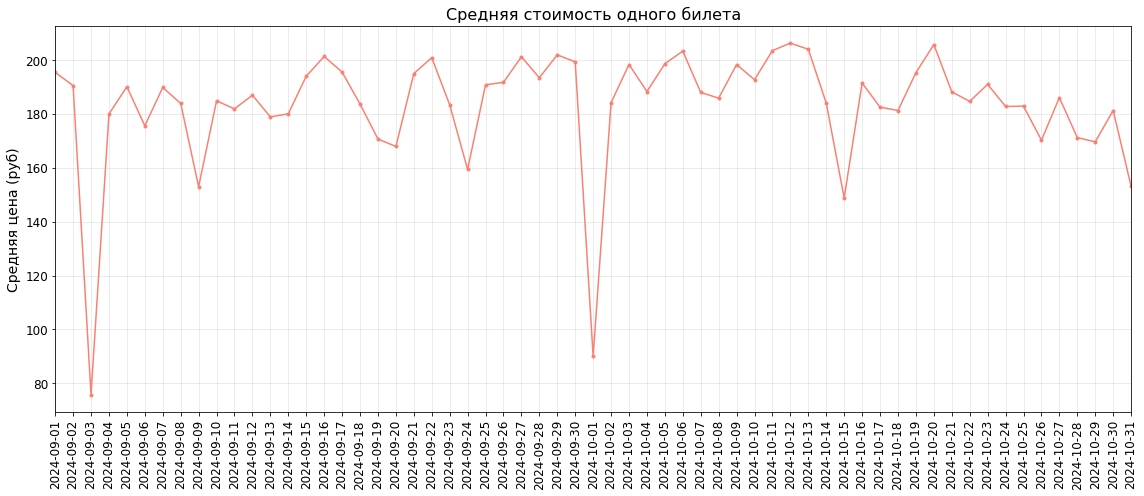

In [57]:
# Построим график для средней стоимости одного билета по дням
plt.figure(figsize=(16, 7))
plt.plot(daily_stats['created_dt_msk'], daily_stats['avg_ticket_price'], marker='o', markersize=3, color='salmon' )
plt.margins(x=0)
plt.title('Средняя стоимость одного билета', fontsize=16)           
plt.xlabel('', fontsize=14)                                    
plt.ylabel('Средняя цена (руб)', fontsize=14)                      
plt.xticks(daily_stats['created_dt_msk'][::1], rotation=90, fontsize=12)  
plt.yticks(fontsize=12)                                             
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- В большинстве дней средняя цена билета держится в диапазоне 150–200 рублей, что является обычным уровнем для осеннего периода.
Минимальные значения зафиксированы:3 сентября — резкое падение до 75 рублей и 1 октября до 90 рублей.

**Общий вывод о о пользовательской активности**
- Осенью наблюдается стабильный рост пользовательской активности — увеличивается как число заказов, так и количество уникальных покупателей.
- Рекордные дни (3 сентября, 1 и 31 октября) характеризуются: максимальным числом заказов, высоким DAU, пиковым числом билетов на пользователя (до 6+), снижением средней цены билета (до 75–90 рублей).
- Снижение цен в пиковые дни указывает на проведение массовых акций или специальных мероприятий с доступными билетами.
- Начало сентября — период низкой активности ("раскачка" после лета), что выражается в минимальных значениях по всем метрикам.\
Оба осенних месяца демонстрируют высокую активность, но с разной структурой:
- Сентябрь — массовые покупки при низких ценах
- Октябрь — максимальное вовлечение аудитории

In [58]:
# Изучим недельную цикличность и сравним пользовательскую активность в будни и выходные
# Добавим день недели 
daily_stats['weekday'] = pd.to_datetime(daily_stats['created_dt_msk']).dt.day_name()
daily_stats['is_weekend'] = daily_stats['weekday'].isin(['Saturday', 'Sunday'])

# Средние показатели по каждому дню недели
weekday_avg = daily_stats.groupby('weekday').agg({
    'total_orders': 'mean',
    'dau': 'mean',
    'orders_per_user': 'mean',
    'avg_ticket_price': 'mean'
}).round(2).reset_index()

# Сортируем дни в правильном порядке
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = weekday_avg.set_index('weekday').loc[weekday_order].reset_index()

print("Средние показатели по дням недели:")
display(weekday_avg)

# Сравним будни и выходные
weekend_avg = daily_stats.groupby('is_weekend').agg({
    'total_orders': 'mean',
    'dau': 'mean',
    'orders_per_user': 'mean',
    'avg_ticket_price': 'mean'
}).round(2).reset_index()

weekend_avg['period'] = weekend_avg['is_weekend'].map({False: 'Будни', True: 'Выходные'})

print("\nСравнение будней и выходных дней:")
display(weekend_avg[['period', 'total_orders', 'dau', 'orders_per_user', 'avg_ticket_price']])

Средние показатели по дням недели:


,weekday,total_orders,dau,orders_per_user,avg_ticket_price
0,Monday,2388.56,853.00,2.78,184.23
1,Tuesday,3493.33,934.11,3.72,154.88
2,Wednesday,2539.33,922.89,2.75,186.85
3,Thursday,3013.00,960.89,3.06,183.11
4,Friday,3101.38,1022.38,3.00,184.84
5,Saturday,2666.12,960.38,2.76,190.97
6,Sunday,2152.78,822.00,2.60,197.13



Сравнение будней и выходных дней:


,period,total_orders,dau,orders_per_user,avg_ticket_price
0,Будни,2902.70,936.75,3.06,178.64
1,Выходные,2394.35,887.12,2.68,194.23


В ходе анализа мы обнаружили, что пик активности приходится на вторник:
- максимальное число заказов (3493)
- максимальное число заказов на пользователя (3.72)
- самая низкая цена билета (154.88 р.)\
Однако ранее мы зафиксировали три аномальных пика(3 сентября, 1 октября, 31 октября) по всем метрикам: общее число заказов, количество активных пользователей DAU, среднее число заказов на одного пользователя, средняя стоимость одного билета.\
Эти дни могли исказить общую статистику по дням недели.\
Чтобы понять, насколько сильно аномалии повлияли на показатели вторника, проверим, на какие дни недели они пришлись.



In [59]:
# Список пиковых дат
peak_dates = ['2024-09-03', '2024-10-01', '2024-10-31']

for date in peak_dates:
    dt = pd.to_datetime(date)
    print(f"{date} — {dt.day_name()}")

2024-09-03 — Tuesday
2024-10-01 — Tuesday
2024-10-31 — Thursday


- Два из трёх аномальных пиков пришлись на вторник, что частично объясняет рекордные показатели этого дня (максимум заказов, максимум заказов на пользователя, минимум цены).
- Четверг также получил дополнительный вклад от пика 31 октября, что могло повлиять на его средние значения.
- Для более точной оценки недельной цикличности уберем эти даты из расчёта средних показателей по дням недели.

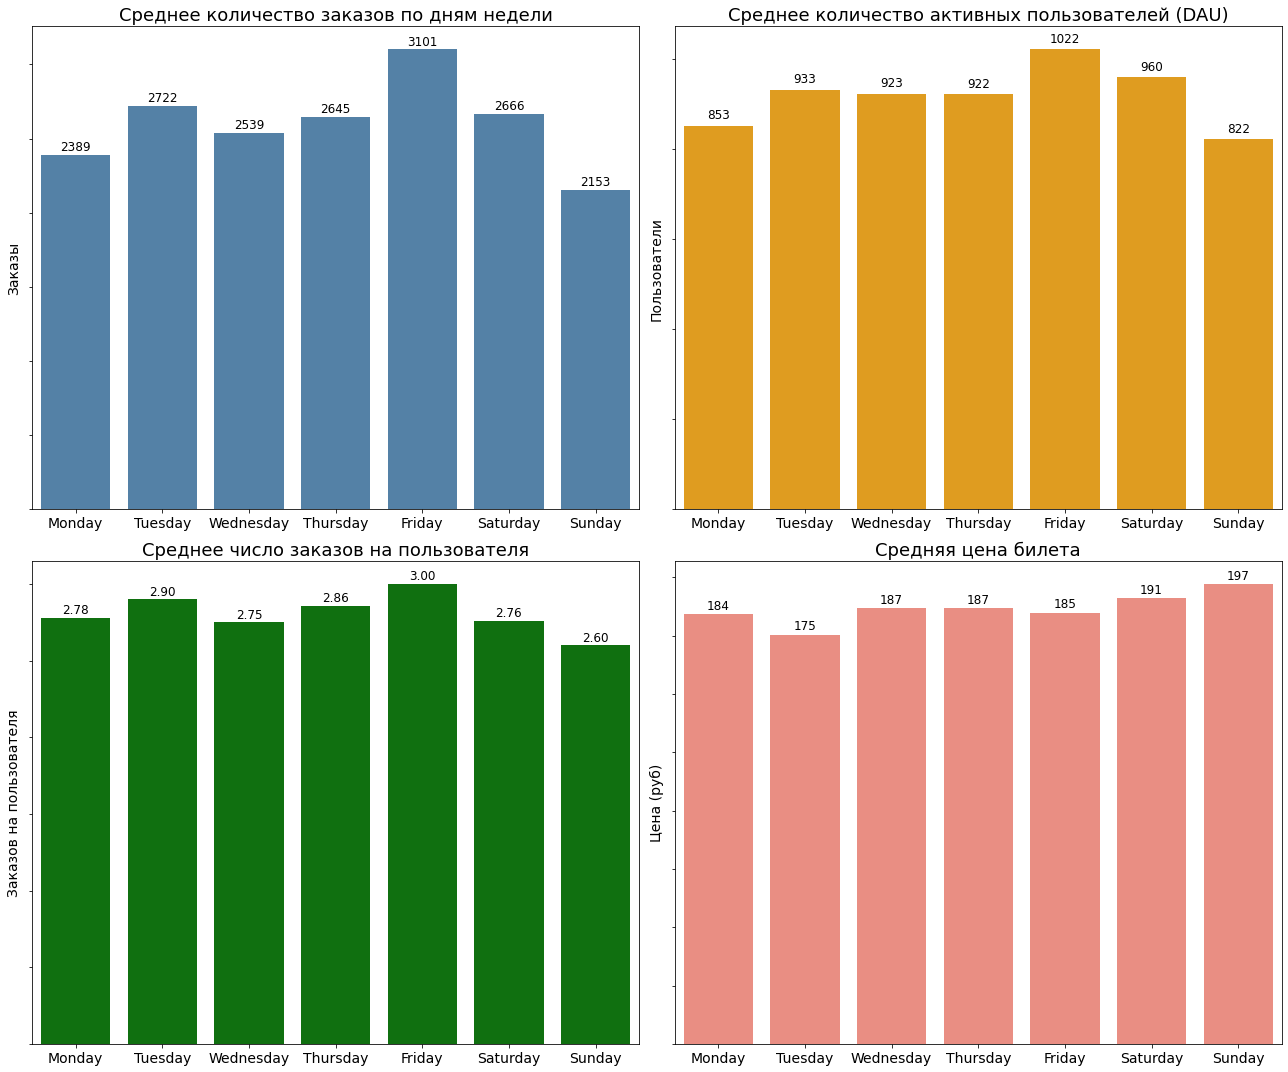

In [60]:
# Исключаем аномальные пиковые даты
peak_dates = ['2024-09-03', '2024-10-01', '2024-10-31']
daily_stats_clean = daily_stats[~daily_stats['created_dt_msk'].isin(pd.to_datetime(peak_dates))].copy()

# Добавим день недели 
daily_stats_clean['weekday'] = pd.to_datetime(daily_stats_clean['created_dt_msk']).dt.day_name()
daily_stats_clean['is_weekend'] = daily_stats_clean['weekday'].isin(['Saturday', 'Sunday'])

# Средние показатели по каждому дню недели
weekday_avg = daily_stats_clean.groupby('weekday').agg({
    'total_orders': 'mean',
    'dau': 'mean',
    'orders_per_user': 'mean',
    'avg_ticket_price': 'mean'
}).round(2).reset_index()

# Сортируем дни в правильном порядке
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = weekday_avg.set_index('weekday').loc[weekday_order].reset_index()

# Построим 4 отдельных графика
fig, axes = plt.subplots(2, 2, figsize=(18, 15))

# 1. Количество заказов
ax1 = sns.barplot(data=weekday_avg, x='weekday', y='total_orders', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Среднее количество заказов по дням недели', fontsize=18)
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Заказы', fontsize=14)
axes[0,0].tick_params(axis='x',labelsize=14)
# Добавляем подписи значений
for i, (idx, row) in enumerate(weekday_avg.iterrows()):
    ax1.text(i, row['total_orders'] + 10, f'{row["total_orders"]:.0f}', 
             ha='center', va='bottom', fontsize=12)
ax1.set_yticklabels([])

# 2. DAU
ax2 = sns.barplot(data=weekday_avg, x='weekday', y='dau', ax=axes[0,1], color='orange')
axes[0,1].set_title('Среднее количество активных пользователей (DAU)', fontsize=18)
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Пользователи', fontsize=14)
axes[0,1].tick_params(axis='x',labelsize=14)
# Добавляем подписи значений
for i, (idx, row) in enumerate(weekday_avg.iterrows()):
    ax2.text(i, row['dau'] + 10, f'{row["dau"]:.0f}', 
             ha='center', va='bottom', fontsize=12)
ax2.set_yticklabels([])

# 3. Заказов на пользователя
ax3 = sns.barplot(data=weekday_avg, x='weekday', y='orders_per_user', ax=axes[1,0], color='green')
axes[1,0].set_title('Среднее число заказов на пользователя', fontsize=18)
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Заказов на пользователя', fontsize=14)
axes[1,0].tick_params(axis='x',labelsize=14)
# Добавляем подписи значений
for i, (idx, row) in enumerate(weekday_avg.iterrows()):
    ax3.text(i, row['orders_per_user'] + 0.01, f'{row["orders_per_user"]:.2f}', 
             ha='center', va='bottom', fontsize=12)
ax3.set_yticklabels([])

# 4. Средняя цена билета
ax4 = sns.barplot(data=weekday_avg, x='weekday', y='avg_ticket_price', ax=axes[1,1], color='salmon')
axes[1,1].set_title('Средняя цена билета', fontsize=18)
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Цена (руб)', fontsize=14)
axes[1,1].tick_params(axis='x', labelsize=14)
# Добавляем подписи значений
for i, (idx, row) in enumerate(weekday_avg.iterrows()):
    ax4.text(i, row['avg_ticket_price'] + 1, f'{row["avg_ticket_price"]:.0f}', 
             ha='center', va='bottom', fontsize=12)
ax4.set_yticklabels([])
plt.tight_layout()
plt.show()

In [61]:
# Сравним будни и выходные
weekend_avg = daily_stats_clean.groupby('is_weekend').agg({
    'total_orders': 'mean',
    'dau': 'mean',
    'orders_per_user': 'mean',
    'avg_ticket_price': 'mean'
}).round(2).reset_index()

weekend_avg['period'] = weekend_avg['is_weekend'].map({False: 'Будни', True: 'Выходные'})

print("\nСравнение будней и выходных дней (без аномалий):")
display(weekend_avg[['period', 'total_orders', 'dau', 'orders_per_user', 'avg_ticket_price']])

# Рассчитаем процентную разницу между буднями и выходными
budni = weekend_avg[weekend_avg['period'] == 'Будни'].iloc[0]
vyhodnye = weekend_avg[weekend_avg['period'] == 'Выходные'].iloc[0]

results = []
metrics = ['total_orders', 'dau', 'orders_per_user', 'avg_ticket_price']
for m in metrics:
    diff = ((budni[m] - vyhodnye[m]) / vyhodnye[m] * 100).round(1)
    results.append({'metric': m, 'diff_%': diff})

diff_df = pd.DataFrame(results)
print("\nПроцентная разница (будни и выходные):")
display(diff_df)


Сравнение будней и выходных дней (без аномалий):


,period,total_orders,dau,orders_per_user,avg_ticket_price
0,Будни,2667.78,928.56,2.85,183.94
1,Выходные,2394.35,887.12,2.68,194.23



Процентная разница (будни и выходные):


,metric,diff_%
0,total_orders,11.4
1,dau,4.7
2,orders_per_user,6.3
3,avg_ticket_price,-5.3


**Общие выводы по недельной цикличности**\
После того, как мы убрали рекордные показатели по трём аномальным дням (3 сентября, 1 октября, 31 октября), мы получили более реалистичную картину на основе усреднённых значений:
- Пятница является лидером по трём усреднённым метрикам: количество заказов (3101), количество активных пользователей (1022), число заказов на пользователя (3.00)
- Воскресенье — день с самой высокой усредненной ценой билета (197 р.), но при этом здесь самые низкие показатели по всем остальным метрикам: количество заказов (2153), активные пользователи (822), число заказов на пользователя (2.60)
- Вторник сохраняет самую низкую цену на билет - 175 р., несмотря на исключение аномалий, приходящихся на этот день.\
Рост заказов в будни (+11.4%) складывается из:
- +4.7% за счёт увеличения числа пользователей
- +6.3% за счёт роста активности каждого пользователя\
При это средняя цена билета в выходные выше на 5.3% - это может потому что в выходные проходят более дорогие мероприятия, меньше скидок и акций (высокий спрос сам по себе), меняется структура аудитории — больше индивидуальных покупателей, готовых платить полную стоимость.

### 3.3. Популярные события и партнёры

In [62]:
# Проведем анализ по регионам
# Группируем по регионам
region_stats = df_clean.groupby('region_name').agg(
    unique_events=('event_id', 'nunique'),      
    total_orders=('order_id', 'count'),        
    total_revenue=('revenue_rub', 'sum')        
).reset_index()

# Добавляем долю заказов от общего числа
total_orders_all = region_stats['total_orders'].sum()
region_stats['orders_perc'] = (region_stats['total_orders'] / total_orders_all * 100).round(2)

# Сортируем по убыванию выручки
region_stats_sorted = region_stats.sort_values('total_revenue', ascending=False)

print("Статистика по регионам (топ-10):")
display(region_stats_sorted.head(10))

# Топ регионов по разнообразию мероприятий
region_diversity = region_stats.sort_values('unique_events', ascending=False)
print("Регионы с наибольшим разнообразием мероприятий (топ-10):")
display(region_diversity[['region_name', 'unique_events', 'total_orders']].head(10))

Статистика по регионам (топ-10):


,region_name,unique_events,total_orders,total_revenue,orders_perc
23,Каменевский регион,5935,89665,55911300.00,31.20
60,Североярская область,3798,43725,22104766.00,15.22
45,Озернинский край,349,10405,9554058.00,3.62
77,Широковская область,1225,16099,8628149.00,5.60
41,Малиновоярский округ,165,6314,5089834.00,2.20
78,Яблоневская область,534,6120,3505458.75,2.13
57,Светополянский округ,1068,7487,3039692.25,2.61
42,Медовская область,503,13891,2927740.75,4.83
52,Речиновская область,701,6266,2630315.50,2.18
39,Лугоградская область,246,4691,2593434.25,1.63


Регионы с наибольшим разнообразием мероприятий (топ-10):


,region_name,unique_events,total_orders
23,Каменевский регион,5935,89665
60,Североярская область,3798,43725
77,Широковская область,1225,16099
57,Светополянский округ,1068,7487
52,Речиновская область,701,6266
74,Травяная область,683,5036
11,Горицветская область,551,5153
61,Серебринская область,541,5586
78,Яблоневская область,534,6120
69,Тепляковская область,528,4384


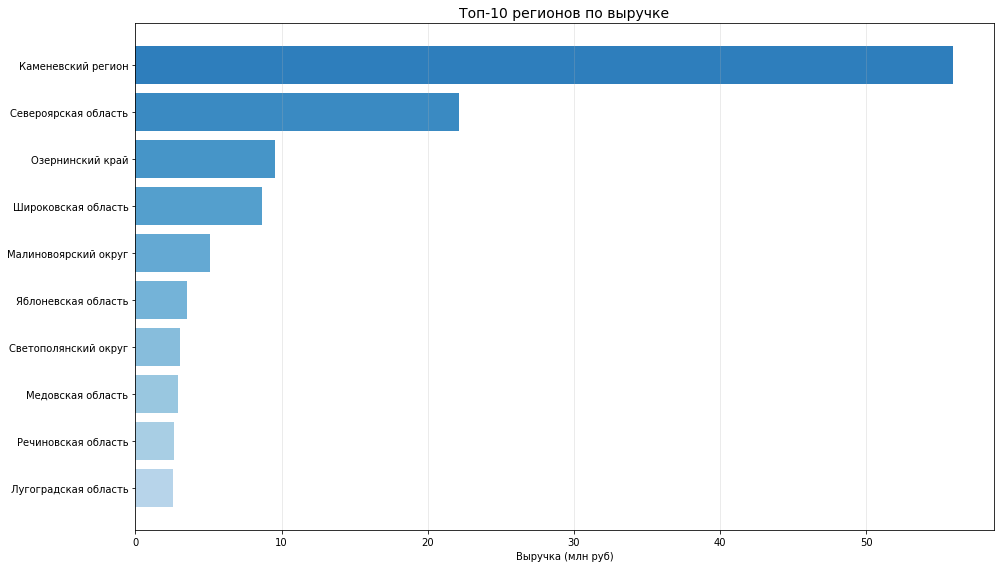

In [63]:
# Построим столбчатую диаграмму для топ-10 регионов
top10_regions = region_stats_sorted.head(10).copy()
top10_regions = top10_regions.sort_values('total_revenue', ascending=True)  # для горизонтальной сортировки
top10_regions['revenue_mln'] = top10_regions['total_revenue'] / 1_000_000
colors = [plt.cm.Blues(i) for i in np.linspace(0.3, 0.7, len(top10_regions))]

plt.figure(figsize=(14, 8))
bars = plt.barh(top10_regions['region_name'], top10_regions['revenue_mln'], 
                color=colors)

plt.xlabel('Выручка (млн руб)')
plt.ylabel('')
plt.title('Топ-10 регионов по выручке', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

- Явный лидер по всем показателям — `Каменевский регион`:
почти 6 000 уникальных мероприятий, более 89 тыс. заказов (31,2% от всех заказов), выручка 55,9 млн р.
- На втором месте — `Североярская область`:
3 800 мероприятий, 43,7 тыс. заказов (15,2% от всех заказов), выручка 22,1 млн р.
- Топ-2 региона (Каменевский и Североярский) концентрируют 46,4% всех заказов и предлагают наибольшее разнообразие мероприятий.
- `Широковская область` замыкает тройку лидеров по заказам (16 тыс., 5,6% от всех заказов), но значительно уступает первым двум по доле.
- Остальные регионы распределены равномерно, их доля не превышает 5% по отдельности.\
Бизнес сильно сконцентрирован в двух ключевых регионах, которые обеспечивают почти половину всех заказов. 

In [64]:
# Проведем анализ по билетным партнёрам
# Группируем по билетным партнёрам
partner_stats = df_clean.groupby('service_name').agg(
    unique_events=('event_id', 'nunique'),      
    total_orders=('order_id', 'count'),         
    total_revenue=('revenue_rub', 'sum')        
).reset_index()

# Добавляем доли
total_orders_all = partner_stats['total_orders'].sum()
total_revenue_all = partner_stats['total_revenue'].sum()
partner_stats['orders_perc'] = (partner_stats['total_orders'] / total_orders_all * 100).round(2)
partner_stats['revenue_perc'] = (partner_stats['total_revenue'] / total_revenue_all * 100).round(2)

# Сортируем по убыванию выручки
partner_stats_sorted = partner_stats.sort_values('total_revenue', ascending=False)

print("Статистика по билетным партнёрам (топ-10):")
display(partner_stats_sorted.head(10))

# Партнёры с наибольшим числом мероприятий
partner_events = partner_stats.sort_values('unique_events', ascending=False)
print("\nПартнёры с наибольшим разнообразием мероприятий (топ-10):")
display(partner_events[['service_name', 'unique_events', 'total_orders']].head(10))

Статистика по билетным партнёрам (топ-10):


,service_name,unique_events,total_orders,total_revenue,orders_perc,revenue_perc
3,Билеты без проблем,4210,62633,24322602.0,21.80,16.299999
24,Мой билет,1300,34440,22042364.0,11.98,14.770000
25,Облачко,2335,26402,18588614.0,9.19,12.450000
21,Лови билет!,4859,40766,16675517.0,14.19,11.170000
8,Весь в билетах,855,16425,16533231.0,5.72,11.080000
5,Билеты в руки,3517,40188,13194799.0,13.98,8.840000
19,Край билетов,252,6109,6405689.0,2.13,4.290000
26,Прачечная,1026,10222,4746810.5,3.56,3.180000
13,Дом культуры,272,4412,4358656.0,1.54,2.920000
35,Яблоко,714,5004,3868337.0,1.74,2.590000



Партнёры с наибольшим разнообразием мероприятий (топ-10):


,service_name,unique_events,total_orders
21,Лови билет!,4859,40766
3,Билеты без проблем,4210,62633
5,Билеты в руки,3517,40188
25,Облачко,2335,26402
22,Лучшие билеты,1755,17715
24,Мой билет,1300,34440
30,Тебе билет!,1061,5189
26,Прачечная,1026,10222
8,Весь в билетах,855,16425
35,Яблоко,714,5004


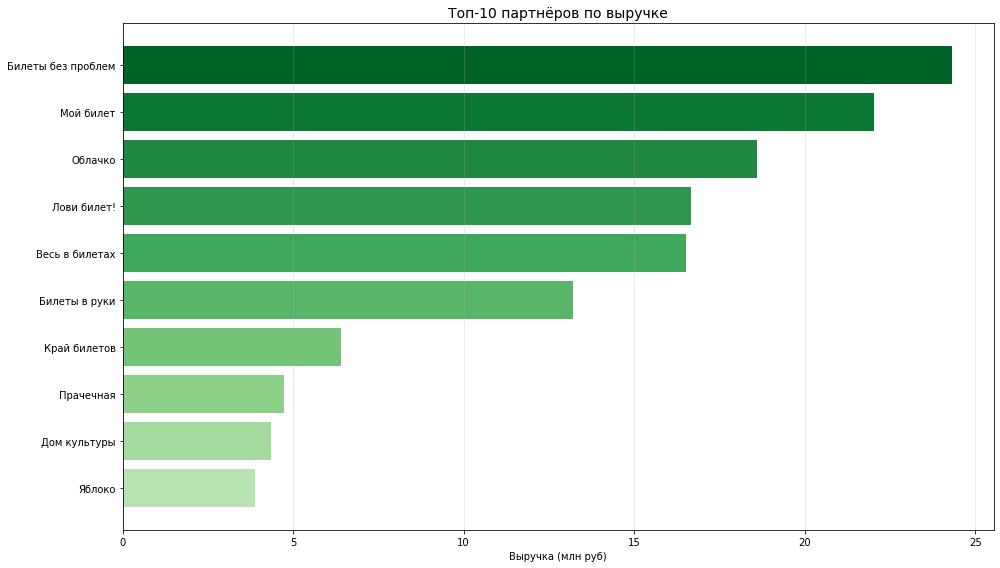

In [65]:
# Построим столбчатую диаграмму для топ-10 партнеров по выручке
top10_partners = partner_stats_sorted.head(10).copy()
top10_partners = top10_partners.sort_values('total_revenue', ascending=True)
top10_partners['revenue_mln'] = top10_partners['total_revenue'] / 1_000_000
colors = [plt.cm.Greens(i) for i in np.linspace(0.3, 0.9, len(top10_partners))]

plt.figure(figsize=(14, 8))
bars = plt.barh(top10_partners['service_name'], top10_partners['revenue_mln'], 
                color=colors)

plt.xlabel('Выручка (млн руб)')
plt.ylabel('')
plt.title('Топ-10 партнёров по выручке', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

- Топ-5 партнёра по выручке ("Билеты без проблем", "Мой билет", "Облачко", "Лови билет!", "Весь в билетах") концентрируют около 66% всей выручки
- "Лови билет!" лидирует по разнообразию, но находится на 4 месте по выручке
- "Билеты без проблем" лидирует по выручке(16.2%) и находится на втором месте с разнообразием мероприятий
- Остальные партнеры приносят 2-8% выручки и не отличаются сильным разнообразием мероприятий

##  4. Статистический анализ данных

Мы будем проверять несколько гипотез.

Гипотеза 1. Среднее количество заказов на пользователя.
- Нулевая гипотеза H₀: Среднее количество заказов на одного пользователя мобильного приложения НЕ выше по сравнению с пользователями стационарных устройств.\
(μ_mobile ≤ μ_desktop).

- Альтернативная гипотеза H₁: Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств\
(μ_mobile > μ_desktop).

Гипотеза 2. Среднее время между заказами.
- Нулевая гипотеза H₀: Среднее время между заказами пользователей мобильных приложений НЕ выше по сравнению с пользователями стационарных устройств.\
(μ_mobile ≤ μ_desktop).
- Альтернативная гипотеза H₁: Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.\
(μ_mobile > μ_desktop).

In [66]:
# Для первой гипотезы посчитаем количество заказов на каждого пользователя по типам устройств
user_orders = autumn_df.groupby(['user_id', 'device_type_canonical'])['order_id'].count().reset_index()
user_orders.columns = ['user_id', 'device_type', 'orders_count']

# Разделяем по устройствам
orders_mobile = user_orders[user_orders['device_type'] == 'mobile']['orders_count']
orders_desktop = user_orders[user_orders['device_type'] == 'desktop']['orders_count']

print(f"Мобильных пользователей: {len(orders_mobile)}")
print(f"Стационарных пользователей: {len(orders_desktop)}")

Мобильных пользователей: 14184
Стационарных пользователей: 4868


Количество пользователей,которые делают заказы через мобильные устройства сильно превышают количество стационарных пользователей. Проверим, не попали ли пользователи в две группы одновременно.

In [67]:
mobile_users = autumn_df[autumn_df['device_type_canonical'] == 'mobile']['user_id']
desktop_users = autumn_df[autumn_df['device_type_canonical'] == 'desktop']['user_id']

intersection = list(set(mobile_users) & set(desktop_users))
print(f"Количество пользователей с обоими типами устройств: {len(intersection)}")

Количество пользователей с обоими типами устройств: 3249


3249 пользователей одновременно делают заказы через мобильное и стационарное устройство.
Такие пользователи должны быть исключены из анализа, потому что:
- они попадают в обе группы одновременно, что нарушает чистоту эксперимента
- на их поведение влияют оба типа устройств, и мы не можем сказать, что именно повлияло на результат
- если их оставить, результаты тестов будут смещёнными

In [68]:
# Исключаем пользователей, которые используют оба типа устройств
if len(intersection) > 0:
    autumn_clean = autumn_df[~autumn_df['user_id'].isin(intersection)].copy()
else:
    autumn_clean = autumn_df.copy()

In [69]:
# Повторно проверяем пересечение между мобильными и стационарными пользователями после очистки
mobile_clean = autumn_clean[autumn_clean['device_type_canonical'] == 'mobile']['user_id']
desktop_clean = autumn_clean[autumn_clean['device_type_canonical'] == 'desktop']['user_id']

intersection_clean = set(mobile_clean) & set(desktop_clean)
print(f'Пересечений между группами после очистки: {len(intersection_clean)}')

Пересечений между группами после очистки: 0


In [70]:
# После чистки снова для первой гипотезы посчитаем количество заказов на каждого пользователя по типам устройств
user_orders_clean = autumn_clean.groupby(['user_id', 'device_type_canonical'])['order_id'].count().reset_index()
user_orders_clean.columns = ['user_id', 'device_type', 'orders_count']

# Разделяем по устройствам
orders_mob = user_orders_clean[user_orders_clean['device_type'] == 'mobile']['orders_count']
orders_desk = user_orders_clean[user_orders_clean['device_type'] == 'desktop']['orders_count']

print(f"Мобильных пользователей после очистки: {len(orders_mob)}")
print(f"Стационарных пользователей после очистки: {len(orders_desk)}")

Мобильных пользователей после очистки: 10935
Стационарных пользователей после очистки: 1619


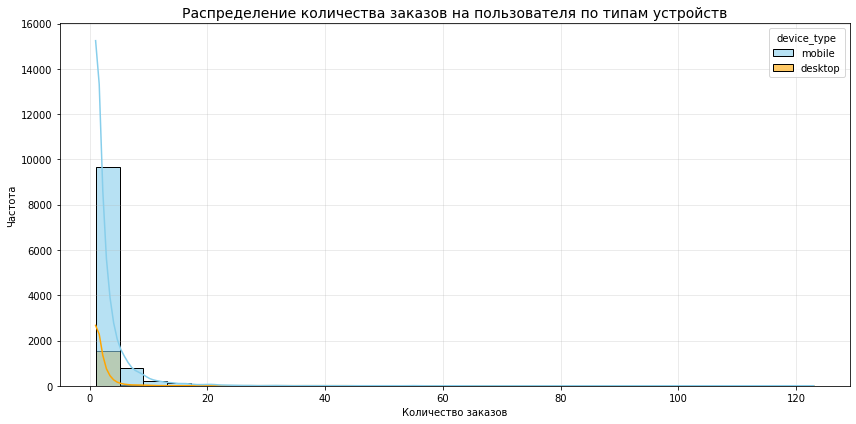

In [71]:
# Посмотрим распределение данных
plot_data = pd.DataFrame({
    'orders_count': pd.concat([orders_mob, orders_desk]),
    'device_type': ['mobile'] * len(orders_mob) + ['desktop'] * len(orders_desk)
})

plt.figure(figsize=(12, 6))
sns.histplot(data=plot_data, x='orders_count', hue='device_type', 
             kde=True, bins=30, alpha=0.6, palette=['skyblue', 'orange'])

plt.title('Распределение количества заказов на пользователя по типам устройств', fontsize=14)
plt.xlabel('Количество заказов')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Уберем выбросы по 99-му процентилю и снова посмотрим на распределение

In [72]:
# Удалим выбросы по 99 процентилю для количества заказов на пользователя
percentile_99_mobile = orders_mob.quantile(0.99)
percentile_99_desktop = orders_desk.quantile(0.99)

print(f"99-й процентиль (mobile): {percentile_99_mobile:.0f} заказов")
print(f"99-й процентиль (desktop): {percentile_99_desktop:.0f} заказов")

# Фильтруем данные
orders_mob_clean = orders_mob[orders_mob <= percentile_99_mobile]
orders_desk_clean = orders_desk[orders_desk <= percentile_99_desktop]

print(f"\nМобильных пользователей до: {len(orders_mob)}")
print(f"Мобильных пользователей после: {len(orders_mob_clean)}")
print(f"Стационарных пользователей до: {len(orders_desk)}")
print(f"Стационарных пользователей после: {len(orders_desk_clean)}")

99-й процентиль (mobile): 20 заказов
99-й процентиль (desktop): 12 заказов

Мобильных пользователей до: 10935
Мобильных пользователей после: 10840
Стационарных пользователей до: 1619
Стационарных пользователей после: 1604


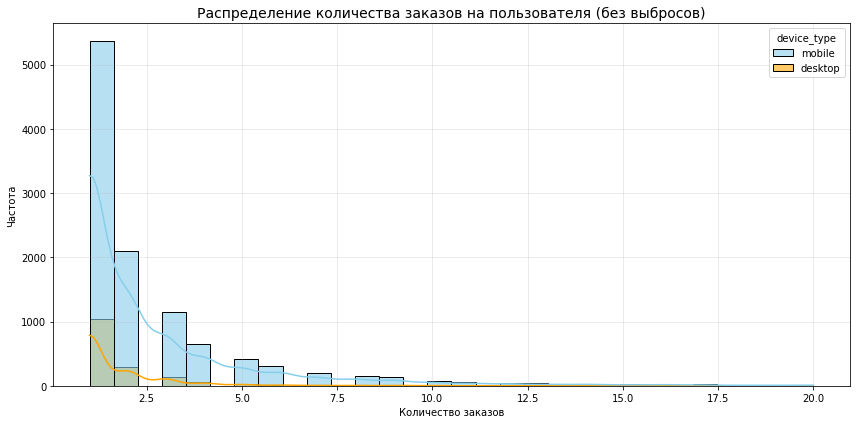

In [73]:
# Снова посмотрим распределение без выбросов
plot_data_clean = pd.DataFrame({
    'orders_count': pd.concat([orders_mob_clean, orders_desk_clean]),
    'device_type': ['mobile'] * len(orders_mob_clean) + ['desktop'] * len(orders_desk_clean)
})

plt.figure(figsize=(12, 6))
sns.histplot(data=plot_data_clean, x='orders_count', hue='device_type', 
             kde=True, bins=30, alpha=0.6, palette=['skyblue', 'orange'])

plt.title('Распределение количества заказов на пользователя (без выбросов)', fontsize=14)
plt.xlabel('Количество заказов')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

По гистограмме распределения без выбросов мы можем сделать следующие выводы:
- распределения для обоих типов устройств имеют схожую форму с положительной асимметрией (смещение вправо)
- пик распределения приходится на 1–2.5 заказа на пользователя
- после удаления выбросов максимальное значение не превышает 17.5 заказов
- удалено менее 1% данных — на общую картину не влияет
- мобильные устройства доминируют по объёму выборки (10 825 и 1 604), что соответствует естественному распределению пользователей

In [74]:
# Посмотрим средние значения и медиану по количеству заказов для каждого типа устройств
stats_orders = pd.DataFrame({
    'device': ['mobile', 'desktop'],
    'mean': [orders_mob_clean.mean(), orders_desk_clean.mean()],
    'median': [orders_mob_clean.median(), orders_desk_clean.median()]
})

print("Средние и медианные значения количества заказов на пользователя:")
print(stats_orders.to_string(index=False))

Средние и медианные значения количества заказов на пользователя:
 device     mean  median
 mobile 2.600554     2.0
desktop 1.741272     1.0


`Анализ средних и медиан количества заказов на пользователя показал:`
- в обеих группах наблюдается правосторонняя асимметрия распределения:
это указывает на наличие "супер-покупателей" с высокими значениями, которые смещают среднее вверх относительно типичного пользователя.\
`Сравнение типов устройств:`
- по среднему значению: мобильные пользователи опережают стационарных на 0.83 заказа (2.58 против 1.74)
- по медиане: мобильные пользователи опережают стационарных в 2 раза (2.0 против 1.0)
Различие в медианах является практически значимым и указывает на принципиально разное поведение групп.

`Обоснование выбора статистического теста:`
- объемы выборок достаточно велики (10 825 и 1 604) и сильно различаются
- группы пользователей не пересекаются (после очистки)
- распределения имеют схожую форму, но дисперсии могут различаться
- центральная предельная теорема обеспечивает нормальность распределения выборочных средних

Таким образом, для проверки гипотезы о том, что среднее количество заказов у мобильных пользователей выше, чем у стационарных, корректно использовать односторонний t-тест Уэлча (с поправкой на неравные дисперсии).

In [75]:
# Данные для теста
mobile_orders = orders_mob_clean  
desktop_orders = orders_desk_clean 

alpha = 0.05

stat, p_value = ttest_ind(
    mobile_orders, 
    desktop_orders, 
    equal_var=False,      
    alternative='greater' 
)

if p_value < alpha:
    print(f'p-value теста Уэлча = {round(p_value, 4)}')
    print('Нулевая гипотеза не находит подтверждения! Среднее количество заказов у мобильных пользователей больше, и это различие статистически значимо')
else:
    print(f'p-value теста Уэлча = {round(p_value, 4)}')
    print('Нулевая гипотеза находит подтверждение! Среднее количество заказов не различается')

p-value теста Уэлча = 0.0
Нулевая гипотеза не находит подтверждения! Среднее количество заказов у мобильных пользователей больше, и это различие статистически значимо


p-value ≈ 0.00 — нулевая гипотеза отвергается на высоком уровне значимости. Мобильные пользователи действительно совершают больше покупок, и это подтверждается на высоком уровне статистической значимости.

**Теперь переходим ко второй гипотезе.**\
Гипотеза 2. Среднее время между заказами.
- Нулевая гипотеза H₀: Среднее время между заказами пользователей мобильных приложений НЕ выше по сравнению с пользователями стационарных устройств.\
(μ_mobile ≤ μ_desktop).
- Альтернативная гипотеза H₁: Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.\
(μ_mobile > μ_desktop).

Далее подготовим данные для этих гипотез.

In [76]:
# Подготовим данные для второй гипотезы 
# Уберем пропуски в days_since_prev
time_data = autumn_clean[['user_id', 'device_type_canonical', 'days_since_prev']].dropna()

time_mobile = time_data[time_data['device_type_canonical'] == 'mobile']['days_since_prev']
time_desktop = time_data[time_data['device_type_canonical'] == 'desktop']['days_since_prev']

print(f"Мобильных интервалов: {len(time_mobile)}")
print(f"Стационарных интервалов: {len(time_desktop)}")

Мобильных интервалов: 24560
Стационарных интервалов: 2072


In [77]:
# Посмотрим пересечние пользователей в каждой группе
mobile_users_time = set(time_data[time_data['device_type_canonical'] == 'mobile']['user_id'])
desktop_users_time = set(time_data[time_data['device_type_canonical'] == 'desktop']['user_id'])

intersection_time = mobile_users_time & desktop_users_time
print(f"Пользователей с обоими типами устройств: {len(intersection_time)}")

Пользователей с обоими типами устройств: 0


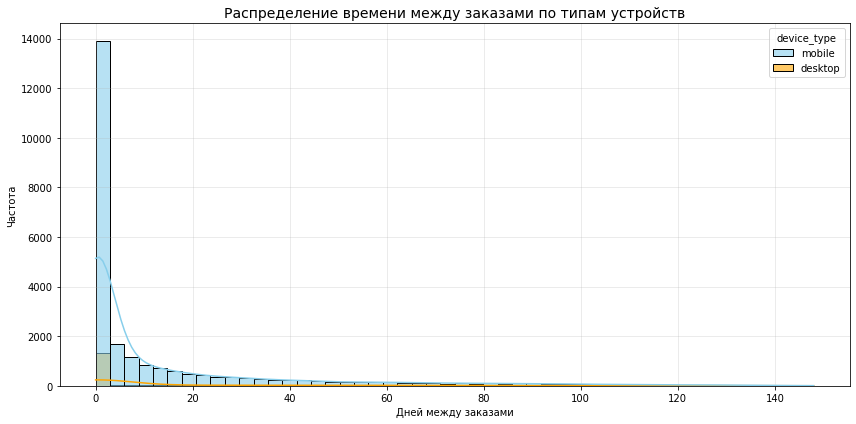

In [78]:
# Посмотрим распределение времени между заказами
plot_data_time = pd.DataFrame({
    'days_between': pd.concat([time_mobile, time_desktop]),
    'device_type': ['mobile'] * len(time_mobile) + ['desktop'] * len(time_desktop)
})

plt.figure(figsize=(12, 6))
sns.histplot(data=plot_data_time, x='days_between', hue='device_type', 
             kde=True, bins=50, alpha=0.6, palette=['skyblue', 'orange'])

plt.title('Распределение времени между заказами по типам устройств', fontsize=14)
plt.xlabel('Дней между заказами')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Мы видим, что 140 дней- это максимальное количество дней между заказами, это почти 5 месяцев. Наш период анализа — сентябрь–октябрь (всего 2 месяца). Такое значение физически не может быть внутри осени.\
Для анализа времени между заказами ограничим данные интервалом в 60 дней.\
Это позволяет исключить межсезонные интервалы, захватывающие заказы за пределами осени, и сфокусироваться на поведении пользователей именно в анализируемом периоде.

In [79]:
# Установим порог в 60 дней (2 месяца)
max_days = 60

time_mobile_clean_60 = time_mobile[time_mobile <= max_days]
time_desktop_clean_60 = time_desktop[time_desktop <= max_days]

print(f"Мобильных интервалов до: {len(time_mobile)}")
print(f"Мобильных интервалов после (≤ {max_days} дней): {len(time_mobile_clean_60)}")
print(f"Стационарных интервалов до: {len(time_desktop)}")
print(f"Стационарных интервалов после (≤ {max_days} дней): {len(time_desktop_clean_60)}")

Мобильных интервалов до: 24560
Мобильных интервалов после (≤ 60 дней): 22712
Стационарных интервалов до: 2072
Стационарных интервалов после (≤ 60 дней): 1796


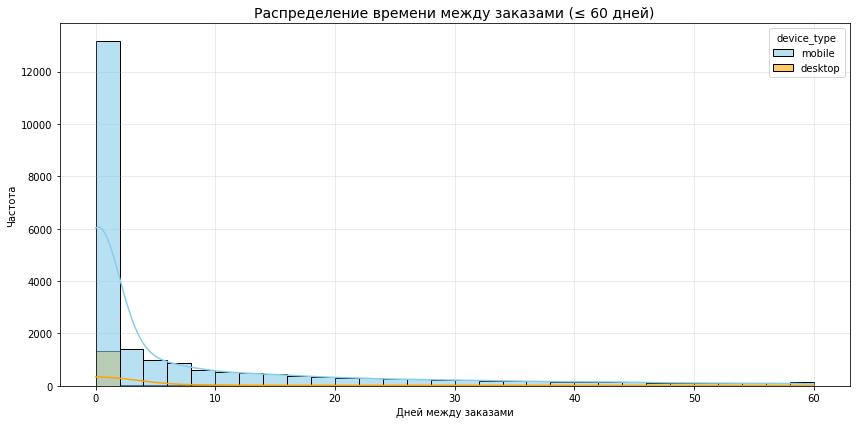

In [80]:
# Снова посмотрим распределение времени между заказами 
plot_data_time_60 = pd.DataFrame({
    'days_between': pd.concat([time_mobile_clean_60, time_desktop_clean_60]),
    'device_type': ['mobile'] * len(time_mobile_clean_60) + ['desktop'] * len(time_desktop_clean_60)
})

plt.figure(figsize=(12, 6))
sns.histplot(data=plot_data_time_60, x='days_between', hue='device_type', 
             kde=True, bins=30, alpha=0.6, palette=['skyblue', 'orange'])
plt.title(f'Распределение времени между заказами (≤ {max_days} дней)', fontsize=14)
plt.xlabel('Дней между заказами')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Анализ распределения времени между заказами (с ограничением в 60 дней) позволяет заключить:
- распределения для обоих типов устройств имеют схожую форму с положительной асимметрией (смещение вправо)
- большинство повторных покупок совершается в течение 1–2 дней с частотой около 12 000 наблюдений, что говорит о высокой повторной активности пользователей в короткие сроки.
- мобильные устройства доминируют по объёму выборки (22 709 и 1 796), что соответствует естественному распределению пользователей

In [81]:
# Посмотрим средние значения и медиану по времени между заказами для каждого типа устройств
stats_time = pd.DataFrame({
    'device': ['mobile', 'desktop'],
    'mean_days': [time_mobile_clean_60.mean(), time_desktop_clean_60.mean()],
    'median_days': [time_mobile_clean_60.median(), time_desktop_clean_60.median()]
})

print("Средние и медианные значения времени между заказами (дней):")
print(stats_time.to_string(index=False))

Средние и медианные значения времени между заказами (дней):
 device  mean_days  median_days
 mobile   7.653443          0.0
desktop   6.843541          0.0


In [82]:
# Проверим долю нулевых интервалов:
mobile_zeros = (time_mobile_clean_60 == 0).mean() * 100
desktop_zeros = (time_desktop_clean_60 == 0).mean() * 100

print(f"Доля нулевых интервалов (mobile): {mobile_zeros:.1f}%")
print(f"Доля нулевых интервалов (desktop): {desktop_zeros:.1f}%")

Доля нулевых интервалов (mobile): 52.1%
Доля нулевых интервалов (desktop): 71.0%


`Анализ средних и медиан времени активности показал:`
- Пользователи очень часто покупают билеты несколько раз в один день (например, на разные мероприятия или для компании)
- Медиана = 0 — не ошибка, а отражение реального поведения:
 - mobile: 52.1% покупок совершаются в тот же день
 - desktop: 71.0% покупок совершаются в тот же день
 
При этом среднее время между заказами у мобильных пользователей выше, что может указывать на их меньшую спонтанность или иные паттерны потребления(например, более осознанное планирование досуга, возможное влияние акций и событий, распределённых во времени)

`Обоснование выбора t-теста:`
Объём выборок достаточно велик:
- mobile: 22 709 интервалов
- desktop: 1 796 интервалов\
Такие размеры позволяют применять параметрические тесты даже при отклонениях от нормальности
- Разброс значений (дисперсии) в группах сильно отличается, что требует использования теста Уэлча (с поправкой на неравные дисперсии)
- Группы пользователей не пересекаются
- Центральная предельная теорема гарантирует, что распределение выборочных средних стремится к нормальному при больших объёмах данных, даже если исходные распределения не нормальны

In [83]:
# Проводим t-тест
time_mobile = time_mobile_clean_60 
time_desktop = time_desktop_clean_60

alpha = 0.05

# Односторонний t-тест Уэлча
stat2, p_value2 = ttest_ind(
    time_mobile, 
    time_desktop, 
    equal_var=False,     
    alternative='greater' 
)

if p_value2 < alpha:
    print(f'p-value теста Уэлча = {round(p_value2, 2)}')
    print('Нулевая гипотеза не находит подтверждения! Среднее время между заказами у мобильных пользователей больше, и это различие статистически значимо')
else:
    print(f'p-value теста Уэлча = {round(p_value2, 2)}')
    print('Нулевая гипотеза находит подтверждение! Среднее время между заказами не различается')

p-value теста Уэлча = 0.01
Нулевая гипотеза не находит подтверждения! Среднее время между заказами у мобильных пользователей больше, и это различие статистически значимо


Гипотеза подтвердилась.\
Мобильные пользователи возвращаются за новыми покупками через более длительные промежутки, чем десктопные.\
Вероятно, мобильные пользователи более осознанно подходят к покупкам и планируют досуг заранее, в отличие от десктоп-пользователей, которые склонны к спонтанным приобретениям.

## 5. Общий вывод и рекомендации

В проекте использовались данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года.
После предобработки итоговый датасет содержит 28 столбцов и 287 371 строк (удалено 1,20 % данных).\
Основные метрики: выручка, количество заказов, число уникальных пользователей, средний чек, количество билетов.

**Основные результаты анализа**\
`Популярность мероприятий:`
- Концерты — абсолютный лидер во все месяцы (доля 36–45% заказов), хотя к осени их популярность немного снижается.
- Театр и другое стабильно занимают 2–3 места, причём театр показывает рост в сентябре.
- Спорт демонстрирует впечатляющий рост с 0,8% в июне до 11,5% в сентябре.
- Ёлки начинают набирать популярность в октябре (1,4%), что связано с приближением новогоднего сезона.

`Сезонность и цены:`
- Общее количество заказов выросло в 3 раза с июня по октябрь.
- Наиболее интенсивный рост пришёлся на сентябрь (+55,5% к августу), что стало началом активного осеннего сезона
- 16+ — безусловный лидер по возрастному рейтингу, во все месяцы (25%–29%), хотя к осени его доля немного снижается.
- рост доли категорий 0+ и спорта при одновременном снижении доли 18+ указывает на омоложение аудитории и смещение интереса в сторону семейного и активного досуга.
- Выставки (+6,0%) и стендап (+5,8%) - единственные категории с ростом цен осенью

`Осенняя активность пользователей:`
- В пиковые дни (3 сентября, 1 и 31 октября) рост заказов сопровождался снижением цены, что подтверждает эластичность спроса — аудитория активно реагирует на скидки.
- Сентябрь — массовые покупки при низких ценах, октябрь — максимальное вовлечение аудитории
Анализ недельной цикличности по усредненным метрикам показал, что:
- Пятница — лидер по трём метрикам: заказы (3101), активные пользователи (1022), заказов на пользователя (3.00)
- Воскресенье — самая высокая цена билета (197 р.), но минимальная активность
- Будни активнее выходных на 11.4% (приходит больше людей (+4.7%), каждый из них покупает чаще (+6.3%)
- В выходные цена билета выше на 5.3% — вероятно, из-за более дорогих мероприятий, отсутствия скидок и иной структуры аудитории.

`Популярные события и партнёры:`
- Каменевский регион — лидер по всем показателям (31,2% заказов и 55,9 млн р выручки).
- Вместе с Североярской областью (15.2% заказов) они дают 46% всех заказов.
- Также,эти два региона  предлагают наибольшее разнообразие мероприятий.
- Топ-5 партнеров по выручке ("Билеты без проблем", "Мой билет", "Облачко", "Лови билет!", "Весь в билетах") концентрируют около 66% всей выручки
- "Лови билет!" лидирует по разнообразию, но находится на 4 месте по выручке
- "Билеты без проблем" лидирует по выручке(16.2%) и находится на втором месте с разнообразием мероприятий
- Остальные партнеры приносят 2-8% выручки и не отличаются сильным разнообразием мероприятий

`Результаты проверки гипотез`\
Гипотеза 1 подтвердилась:
Мобильные пользователи совершают значительно больше заказов (2,58 против 1,74), p-value ≈ 0.00 — нулевая гипотеза отвергается на высоком уровне значимости.

Гипотеза 2 подтвердилась:
Среднее время между заказами у мобильных пользователей выше (7,65 против 6,84 дней), p-value = 0,01.
Это указывает на более осознанное планирование досуга мобильной аудиторией, в то время как десктоп-пользователи склонны к спонтанным покупкам.

**Рекомендации**
- Десктоп-пользователям — предлагать спонтанные акции (скидки на сегодня, flash-распродажи), так как они чаще покупают импульсивно.
- Мобильным пользователям — делать упор на планирование: предпродажи, push-уведомления о новых событиях, интеграция с календарём.
- Фильмы 0+ и спорт — растущие категории осенью. Увеличить количество предложений, добавить семейные и студенческие тарифы.
- Выставки и стендап — единственные категории с ростом цен осенью. Учитывая рост цен при сохранении спроса, можно увеличивать долю этих мероприятий в афише.
- Пятница — самый активный день (максимум заказов, пользователей и заказов на пользователя). Можно использовать для запуска новых мероприятий и основных рекламных кампаний.
- Воскресенье — тестировать премиальные предложения и пакетные предложения для повышения активности.
- Каменевский регион и Североярская область — лидеры по заказам и выручке. Масштабировать их успешные практики на другие регионы.
- «Билеты без проблем» — ключевой партнёр, укреплять сотрудничество.
- «Лови билет!» — помочь монетизировать широкий ассортимент (рекомендации, пакеты).\
Проект подтвердил ключевую роль мобильных устройств, концертов и двух ведущих регионов в бизнесе Яндекс Афиши.
Выявленные паттерны позволяют точечно настраивать маркетинговые активности и оптимизировать ассортимент под разные сегменты аудитории.